In [2]:
import numpy as np
import pandas as pd
import math
import textwrap

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy import stats
from scipy.stats import t, gmean
from itertools import combinations


In [3]:
### Setting global plot features ###

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator, LogLocator, NullFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.style.use('default')

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "font.weight": "normal",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "axes.labelcolor": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "text.color": "black",
    "figure.facecolor": "white",
    "figure.dpi": 150,
    "legend.frameon": True,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "#cccccc",
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "legend.facecolor": "white",
    "lines.linewidth": 1.8,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})

FIT_LINE_COLOR   = "#B03A2E"
RMSE_BAND_COLOR  = "#64A082"
GM_MARKER_COLOR  = "#B07D2A"
REMOVED_PT_COLOR = "#A0293D"
OBS_COLOR        = "#1B3A5C"
REF_LINE_COLOR   = "#B07D2A"

CAP_CLASS_COLORS = {
    "Small":  {"face": "#1B3A5C", "alpha_box": 0.28, "alpha_border": 0.70},
    "Medium": {"face": "#3D6B45", "alpha_box": 0.28, "alpha_border": 0.70},
    "Large":  {"face": "#7A1A2E", "alpha_box": 0.20, "alpha_border": 0.55},
}


In [4]:
def _wrap_label(text, width=12):
    """Wrap long labels onto multiple lines to avoid overlap."""
    return "\n".join(textwrap.wrap(text, width=width)) if len(text) > width else text


SUBTYPE_STYLES = {'Agitated Tanks': {'color': '#2C5F8A', 'marker': 'o', 'linestyle': '-'}}



def plot_pv_histogram(df, column_name, equipment, unit, bins):
    """Histogram of power intensity — publication style."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, col, label in zip(
        axes,
        [column_name.replace('log(','').replace(')',''), column_name],
        ['(a) Raw', '(b) Log-transformed']
    ):
        if col not in df.columns:
            col = column_name
        data = df[col].dropna()
        b = freedman_diaconis_bins(data)
        ax.hist(data, bins=b, color='#1B3A5C', alpha=0.55,
                edgecolor='#1B3A5C', linewidth=0.4)
        ax.set_xlabel("Power intensity [kW·m$^{-3}$]", style='italic', fontsize=10)
        ax.set_ylabel('Count', style='italic', fontsize=10)
        ax.set_title(label, fontsize=10, color='black', style='italic', pad=4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    fig.suptitle(f'Power intensity distribution — {equipment}',
                 fontsize=11, color='black', y=1.01)
    plt.tight_layout()
    plt.show()



def plot_equipment_type_distribution(df, equipment_type="Equipment"):
    """Bar chart of subtype counts — publication style."""
    type_counts = df["Type"].value_counts().sort_values(ascending=False)
    bin_labels = type_counts.index.tolist()
    counts = type_counts.values.tolist()
    x = np.arange(len(bin_labels))
    bar_colors = [SUBTYPE_STYLES.get(t, {}).get("color", "#1B3A5C") for t in bin_labels]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.bar(x, counts, color=bar_colors, alpha=0.60,
                  edgecolor=bar_colors, linewidth=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3, str(count),
                ha='center', va='bottom', fontsize=9, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels([_wrap_label(t, width=10) for t in bin_labels], rotation=0, ha='center', fontsize=9)
    ax.set_xlabel(f"{equipment_type} sub-types", style='italic', fontsize=10)
    ax.set_ylabel(f"Number of {equipment_type}", style='italic', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ymax = math.ceil(max(counts) * 1.18 / 10) * 10
    ax.set_ylim(0, ymax)
    plt.tight_layout()
    plt.show()



def plot_pv_vs_v_by_type(df, type_color_map, equipment_type="Equipment"):
    """Power scale scatter of P/capacity — no fit lines."""
    unique_types = df["Type"].unique()
    fig, ax = plt.subplots(figsize=(8, 6))
    legend_handles = []
    for t in unique_types:
        st = SUBTYPE_STYLES.get(t, {"color": "#333333", "marker": "o"})
        subset = df[df["Type"] == t]
        ax.scatter(subset["Volume_m³"], subset["PowerToCapacity_kW·m⁻³"],
                   color=st["color"], marker=st["marker"],
                   s=18, alpha=0.68, edgecolors=st["color"], linewidths=0.3, zorder=2)
        legend_handles.append(Line2D([0],[0], marker=st["marker"], color='w',
                   markerfacecolor=st["color"], markeredgecolor=st["color"],
                   markersize=6, label=t))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Volume [m$^3$]", style='italic', fontsize=10)
    ax.set_ylabel("Power intensity [kW·m$^{-3}$]", style='italic', fontsize=10)
    ax.legend(handles=legend_handles, title=f"{equipment_type} sub-types",
              fontsize=8, title_fontsize=9, frameon=True,
              facecolor='white', edgecolor='#cccccc', loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()



def plot_logpv_vs_logv_by_type(df, type_color_map, equipment_type="Equipment"):
    """Log-log scatter of P/capacity vs capacity — no fit lines."""
    unique_types = df["Type"].unique()
    fig, ax = plt.subplots(figsize=(8, 6))
    legend_handles = []
    for t in unique_types:
        st = SUBTYPE_STYLES.get(t, {"color": "#333333", "marker": "o"})
        subset = df[df["Type"] == t]
        ax.scatter(subset["log(Capacity)"], subset["log(PowerToCapacity)"],
                   color=st["color"], marker=st["marker"],
                   s=18, alpha=0.68, edgecolors=st["color"], linewidths=0.3, zorder=2)
        legend_handles.append(Line2D([0],[0], marker=st["marker"], color='w',
                   markerfacecolor=st["color"], markeredgecolor=st["color"],
                   markersize=6, label=t))
    ax.set_xlabel("log(V)  [m$^3$]", style='italic', fontsize=10)
    ax.set_ylabel("log(P/V)  [kW·m$^{-3}$]", style='italic', fontsize=10)
    ax.legend(handles=legend_handles, title=f"{equipment_type} sub-types",
              fontsize=8, title_fontsize=9, frameon=True,
              facecolor='white', edgecolor='#cccccc', loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()



def _diag_scatter(ax, obs_x, normal_mask, diag_vals, threshold_vals, ylabel, zero_line=False):
    ax.scatter(obs_x[normal_mask], diag_vals[normal_mask],
               color=OBS_COLOR, alpha=0.60, s=10, linewidths=0.3,
               edgecolors=OBS_COLOR, zorder=2)
    infl = ~normal_mask
    if infl.any():
        ax.scatter(obs_x[infl], diag_vals[infl],
                   color=REMOVED_PT_COLOR, alpha=0.85, s=30,
                   marker='D', linewidths=0.4, edgecolors=REMOVED_PT_COLOR, zorder=3)
    if isinstance(threshold_vals, (list, tuple)):
        for tv in threshold_vals:
            ax.axhline(tv, color='#D4AF37', linewidth=1.0, linestyle='--', zorder=1)
    else:
        ax.axhline(threshold_vals, color='#D4AF37', linewidth=1.0, linestyle='--', zorder=1)
    if zero_line:
        ax.axhline(0, color='#cccccc', linewidth=0.7, zorder=1)
    ax.set_ylabel(ylabel, style='italic', fontsize=9)
    ax.set_xlabel('Observation number', style='italic', fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

def plot_leverage(df_influence, equipment_type, id_col="Entry_No.", mean_lev=None):
    """2x2 influence diagnostics — publication style."""
    obs = df_influence[id_col].values if id_col in df_influence.columns else np.arange(len(df_influence))
    lev = df_influence["Leverage"].values
    sr  = df_influence["StudResid"].values
    dff = df_influence["DFFITS"].values
    cks = df_influence["CooksD"].values
    n = len(obs); k = 1
    if mean_lev is None: mean_lev = lev.mean()
    lev_thresh = 3 * mean_lev
    dff_thresh = 2 * np.sqrt((k + 2) / (n - k - 2))
    cks_thresh = 4 / n
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle(f'Influence diagnostics — {equipment_type}', fontsize=11, color='black', y=1.01)
    _diag_scatter(axes[0,0], obs, lev <= lev_thresh,  lev, lev_thresh,  'Leverage')
    _diag_scatter(axes[0,1], obs, np.abs(sr) < 3,     sr,  [-3, 3],     'Studentized residual', zero_line=True)
    _diag_scatter(axes[1,0], obs, np.abs(dff) < dff_thresh, dff, [-dff_thresh, dff_thresh], 'DFFITS', zero_line=True)
    _diag_scatter(axes[1,1], obs, cks <= cks_thresh,  cks, cks_thresh,  "Cook's distance")
    legend_els = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=OBS_COLOR,       markersize=6, label='Normal'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=REMOVED_PT_COLOR, markersize=6, label='Influential'),
        Line2D([0],[0], color='#D4AF37', linewidth=1, linestyle='--',            label='Threshold'),
    ]
    fig.legend(handles=legend_els, loc='lower center', ncol=3, fontsize=9,
               frameon=True, facecolor='white', edgecolor='#cccccc', bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout(); plt.show()



def plot_fit_unified(df, x_col, y_col, df_coefs, df_model,
                     equipment_type="", capacity_type="V",
                     loglog=True, df_influential=None):
    """Log-log or power-scale fit plot — publication style."""
    coefs    = df_coefs["Coefficient"].astype(float).values
    rmse_log = float(df_model["RMSE"].iloc[0])
    r2adj    = float(df_model["R2_adj"].iloc[0])
    x = df[x_col].values; y = df[y_col].values
    terms = []
    for i, c in enumerate(coefs):
        if i == 0: terms.append(f"{c:.4f}")
        elif i == 1: terms.append(f"{c:+.4f} log(V)")
        else: terms.append(f"{c:+.4f} log(V)^{i}")
    eq_str = " ".join(terms)

    if loglog:
        x_sorted = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        y_fit = sum(c * x_sorted**i for i, c in enumerate(coefs))
        fig, ax = plt.subplots(figsize=(7, 5.5))
        ax.fill_between(x_sorted, y_fit - rmse_log, y_fit + rmse_log,
                        color=RMSE_BAND_COLOR, alpha=0.20, zorder=1)
        ax.plot(x_sorted, y_fit + rmse_log, color=RMSE_BAND_COLOR, linewidth=0.7, linestyle='--', alpha=0.55, zorder=2)
        ax.plot(x_sorted, y_fit - rmse_log, color=RMSE_BAND_COLOR, linewidth=0.7, linestyle='--', alpha=0.55, zorder=2)
        ax.scatter(x, y, color=OBS_COLOR, s=12, alpha=0.60, edgecolors=OBS_COLOR, linewidths=0.3, zorder=3)
        if df_influential is not None and not df_influential.empty:
            if x_col in df_influential.columns and y_col in df_influential.columns:
                ax.scatter(df_influential[x_col], df_influential[y_col],
                           color=REMOVED_PT_COLOR, marker='D', s=35, alpha=0.85,
                           edgecolors=REMOVED_PT_COLOR, linewidths=0.4, zorder=4,
                           label='Removed influential points')
        ax.plot(x_sorted, y_fit, color=FIT_LINE_COLOR, linewidth=2.0, zorder=5)
        ax.set_xlabel(f"log(V)  [m$^3$]", style='italic', fontsize=10)
        ax.set_ylabel("log(P/V)  [kW·m$^{-3}$]", style='italic', fontsize=10)
        legend_els = [
            Line2D([0],[0], marker='o', color='w', markerfacecolor=OBS_COLOR, markersize=6, label='Observations'),
            Line2D([0],[0], marker='D', color='w', markerfacecolor=REMOVED_PT_COLOR, markersize=6, label='Removed points'),
            Line2D([0],[0], color=FIT_LINE_COLOR, linewidth=2, label='OLS fit'),
            Patch(facecolor=RMSE_BAND_COLOR, alpha=0.35, label=f'\u00b1RMSE ({rmse_log:.4f})'),
        ]
        ax.legend(handles=legend_els, fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
        ax.text(0.03, 0.05,
                f"log(P/V) = {eq_str}\n$R^2_{{adj}}$ = {r2adj:.4f}",
                transform=ax.transAxes, fontsize=8.5, color='black', verticalalignment='bottom',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f8f8', edgecolor='#dddddd', alpha=0.9))
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.tight_layout(); plt.show()
        return

    # RAW scale
    mask_pos = (x > 0) & (y > 0)
    x_pos, y_pos = x[mask_pos], y[mask_pos]
    x_sorted = np.logspace(np.log10(x_pos.min()), np.log10(x_pos.max()), 200)
    logx_s   = np.log10(x_sorted)
    y_fit    = 10 ** sum(c * logx_s**i for i, c in enumerate(coefs))
    mult     = 10 ** rmse_log
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.fill_between(x_sorted, y_fit / mult, y_fit * mult,
                    color=RMSE_BAND_COLOR, alpha=0.20, zorder=1)
    ax.plot(x_sorted, y_fit * mult, color=RMSE_BAND_COLOR, linewidth=0.7, linestyle='--', alpha=0.55, zorder=2)
    ax.plot(x_sorted, y_fit / mult, color=RMSE_BAND_COLOR, linewidth=0.7, linestyle='--', alpha=0.55, zorder=2)
    ax.scatter(x, y, color=OBS_COLOR, s=12, alpha=0.60, edgecolors=OBS_COLOR, linewidths=0.3, zorder=3)
    if df_influential is not None and not df_influential.empty:
        if x_col in df_influential.columns and y_col in df_influential.columns:
            ax.scatter(df_influential[x_col], df_influential[y_col],
                       color=REMOVED_PT_COLOR, marker='D', s=35, alpha=0.85,
                       edgecolors=REMOVED_PT_COLOR, linewidths=0.4, zorder=4)
    ax.plot(x_sorted, y_fit, color=FIT_LINE_COLOR, linewidth=2.0, zorder=5)
    ax.set_xlabel("Volume [m$^3$]", style='italic', fontsize=10)
    ax.set_ylabel("Power intensity [kW·m$^{-3}$]", style='italic', fontsize=10)
    legend_els = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=OBS_COLOR, markersize=6, label='Observations'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=REMOVED_PT_COLOR, markersize=6, label='Removed points'),
        Line2D([0],[0], color=FIT_LINE_COLOR, linewidth=2, label='OLS fit'),
        Patch(facecolor=RMSE_BAND_COLOR, alpha=0.35, label='RMSE interval'),
    ]
    ax.legend(handles=legend_els, fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
    ax.text(0.03, 0.05,
            f"P/V = 10^({eq_str})\n$R^2_{{adj}}$ = {r2adj:.4f}",
            transform=ax.transAxes, fontsize=8.5, color='black', verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f8f8', edgecolor='#dddddd', alpha=0.9))
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()



def regression_diagnostics(x_log, y_log, equipment_type, degree=1):
    """Residuals vs fitted + Q-Q — publication style."""
    X_poly    = np.vander(x_log, degree + 1, increasing=True)
    model     = sm.OLS(y_log, X_poly).fit()
    fitted    = model.fittedvalues
    residuals = model.resid
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    ax = axes[0]
    ax.scatter(fitted, residuals, color=OBS_COLOR, s=14, alpha=0.60,
               edgecolors=OBS_COLOR, linewidths=0.3, zorder=2)
    ax.axhline(0, color=REF_LINE_COLOR, linewidth=1.4, linestyle='--', zorder=1)
    ax.set_xlabel("Fitted values (log scale)", style='italic', fontsize=10)
    ax.set_ylabel("Residuals", style='italic', fontsize=10)
    ax.set_title("(a) Residuals vs fitted", fontsize=10, color='black', style='italic', pad=4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax2 = axes[1]
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
    ax2.scatter(osm, osr, color=OBS_COLOR, s=14, alpha=0.60,
                edgecolors=OBS_COLOR, linewidths=0.3, zorder=2)
    qqx = np.array([osm.min(), osm.max()])
    ax2.plot(qqx, slope * qqx + intercept, color=REF_LINE_COLOR, linewidth=1.4, zorder=1)
    ax2.set_xlabel("Theoretical quantiles", style='italic', fontsize=10)
    ax2.set_ylabel("Sample quantiles", style='italic', fontsize=10)
    ax2.set_title("(b) Normal Q\u2013Q", fontsize=10, color='black', style='italic', pad=4)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    plt.suptitle(f'Assumption check \u2014 {equipment_type}', fontsize=11, color='black', y=1.01)
    plt.tight_layout(); plt.show(); plt.close()
    n = len(residuals)
    if n < 50:
        stat, p = stats.shapiro(residuals)
        test_name = "Shapiro\u2013Wilk Test (Normality)"
    else:
        stat, p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals, ddof=1)))
        test_name = "Kolmogorov\u2013Smirnov Test (Normality)"
    bp_test = het_breuschpagan(residuals, X_poly)
    bp_stat, bp_pval = bp_test[0], bp_test[1]
    print(f"{test_name}:")
    print(f"  Statistic = {stat:.4f}, p-value = {p:.4g}")
    print("  \u2705 Residuals appear normal." if p >= 0.05 else "  \u274c Residuals not normal.")
    print("\nBreusch-Pagan Test (Heteroscedasticity):")
    print(f"  LM-statistic = {bp_stat:.4f}, p-value = {bp_pval:.4g}")
    print("  \u2705 No evidence of heteroscedasticity." if bp_pval >= 0.05 else "  \u274c Evidence of heteroscedasticity.")
    return model



def plot_capacity_distribution(bin_labels, counts, capacity_unit, equipment_type):
    """Bar chart of capacity bin counts — publication style."""
    if "_" in capacity_unit:
        cap_name, cap_unit = capacity_unit.split("_", 1)
        cap_unit = cap_unit.replace("\u00b2", "$^2$").replace("\u00b3", "$^3$")
    else:
        cap_name, cap_unit = capacity_unit, ""
    x = np.arange(len(bin_labels))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(x, counts, color=OBS_COLOR, alpha=0.55, edgecolor=OBS_COLOR, linewidth=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3, str(count),
                ha='center', va='bottom', fontsize=9, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, fontsize=9)
    ax.set_xlabel(f"{cap_name} range [{cap_unit}]", style='italic', fontsize=10)
    ax.set_ylabel(f"Number of {equipment_type}", style='italic', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ymax = math.ceil(max(counts) * 1.18 / 10) * 10
    ax.set_ylim(0, ymax)
    plt.tight_layout(); plt.show()



def plot_power_to_capacity_boxplot(df, y_col, splits, bin_labels, capacity_unit, equipment_type):
    """Boxplot P/capacity by capacity class — publication style."""
    if "_" in capacity_unit:
        cap_name, cap_unit = capacity_unit.split("_", 1)
        cap_unit = cap_unit.replace("\u00b2", "$^2$").replace("\u00b3", "$^3$")
    else:
        cap_name, cap_unit = capacity_unit, ""
    groups = []
    start = 0
    for size in splits:
        groups.append(df[y_col].iloc[start:start + size].values)
        start += size
    fig, ax = plt.subplots(figsize=(6, 5))
    cap_face   = [OBS_COLOR, "#3D6B45", "#7A1A2E"]
    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops=dict(color='#333333', linewidth=1.6),
                    whiskerprops=dict(linewidth=0.8, linestyle='--', color='#888888'),
                    capprops=dict(linewidth=0.8, color='#888888'),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                    markerfacecolor='#888888', markeredgecolor='#888888'))
    for patch, fc in zip(bp['boxes'], cap_face):
        patch.set_facecolor(fc); patch.set_alpha(0.28)
        patch.set_edgecolor(fc); patch.set_linewidth(0.9)
    geo_means = [gmean(grp[grp > 0]) if np.any(grp > 0) else np.nan for grp in groups]
    for i, gm in enumerate(geo_means, start=1):
        if not np.isnan(gm):
            ax.scatter(i, gm, color=GM_MARKER_COLOR, marker='^', s=50, zorder=4)
            ax.text(i, gm * 1.08, f"{gm:.2f}", ha='center', va='bottom',
                    fontsize=8.5, color=GM_MARKER_COLOR)
    ax.set_yscale('log')
    ax.set_xticklabels(bin_labels, fontsize=9)
    ax.set_xlabel(f"{equipment_type} {cap_name} range [{cap_unit}]", style='italic', fontsize=10)
    ax.set_ylabel("P/V  [kW·m$^{-3}$]", style='italic', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    legend_els = [
        Patch(facecolor=cap_face[0], alpha=0.35, edgecolor=cap_face[0], label='Small'),
        Patch(facecolor=cap_face[1], alpha=0.35, edgecolor=cap_face[1], label='Medium'),
        Patch(facecolor=cap_face[2], alpha=0.25, edgecolor=cap_face[2], label='Large'),
        Line2D([0],[0], marker='^', color='w', markerfacecolor=GM_MARKER_COLOR, markersize=7, label='Geometric mean'),
    ]
    ax.legend(handles=legend_els, fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
    plt.tight_layout(); plt.show()



def plot_subtype_boxplots_grouped(df, y_col, equipment_col, splits, bin_labels,
                                   capacity_unit, equipment_type):
    """Grouped boxplots of power intensity by capacity class."""
    if "_" in capacity_unit:
        cap_name, cap_unit = capacity_unit.split("_", 1)
        cap_unit = cap_unit.replace("\u00b2", "$^2$").replace("\u00b3", "$^3$")
    else:
        cap_name, cap_unit = capacity_unit, ""
    cap_face  = {"Small": OBS_COLOR, "Medium": "#3D6B45", "Large": "#7A1A2E"}
    cap_alpha = {"Small": 0.28, "Medium": 0.28, "Large": 0.20}
    bins = []
    for size, label in zip(splits, bin_labels):
        bins.extend([label] * size)
    # trim or pad bins list if it does not match dataframe length
    n_rows = len(df)
    if len(bins) != n_rows:
        print(f"\u26a0\ufe0f  Warning: splits sum to {len(bins)} but df has {n_rows} rows. "
              f"Adjusting last bin to match. Verify your splits if this is unexpected.")
        if len(bins) > n_rows:
            bins = bins[:n_rows]
        else:
            bins.extend([bin_labels[-1]] * (n_rows - len(bins)))
    df = df.copy(); df["Bin"] = bins
    df_all = df.copy(); df_all[equipment_col] = f"All {equipment_type}"
    df = pd.concat([df, df_all], ignore_index=True)
    gm_per_type = (df.groupby(equipment_col)[y_col]
                   .apply(lambda g: gmean(g[g > 0]) if np.any(g > 0) else np.nan)
                   .sort_values(ascending=False))
    ordered_types = [t for t in gm_per_type.index if t != f"All {equipment_type}"] + [f"All {equipment_type}"]
    fig, ax = plt.subplots(figsize=(14, 7))
    positions = np.arange(len(ordered_types))
    width = 0.25
    for j, label in enumerate(bin_labels):
        pos = positions + (j - 1) * width
        data = []
        for et in ordered_types:
            vals = df.loc[(df[equipment_col] == et) & (df["Bin"] == label), y_col].values
            data.append(vals if len(vals) > 0 else [np.nan])
        r = int(cap_face[label][1:3], 16)
        g_ = int(cap_face[label][3:5], 16)
        b_ = int(cap_face[label][5:7], 16)
        fc = (r/255, g_/255, b_/255, cap_alpha[label])
        bp = ax.boxplot(data, positions=pos, widths=width * 0.82,
                        patch_artist=True,
                        medianprops=dict(color='#333333', linewidth=1.4),
                        whiskerprops=dict(linewidth=0.7, linestyle='--', color='#aaaaaa'),
                        capprops=dict(linewidth=0.7, color='#aaaaaa'),
                        flierprops=dict(marker='o', markersize=2.5, alpha=0.35,
                                        markerfacecolor='#aaaaaa', markeredgecolor='#aaaaaa'))
        for patch in bp['boxes']:
            patch.set_facecolor(fc); patch.set_edgecolor(cap_face[label]); patch.set_linewidth(0.8)
        for i, et in enumerate(ordered_types):
            vals = df.loc[(df[equipment_col] == et) & (df["Bin"] == label), y_col].values
            vals = vals[vals > 0]
            if len(vals) == 0: continue
            gm = gmean(vals)
            ax.scatter(pos[i], gm, color=GM_MARKER_COLOR, marker='^', s=40, zorder=3)
            ax.text(pos[i] + 0.13, gm, f"{gm:.2f}", ha='left', va='center',
                    fontsize=7.5, color=GM_MARKER_COLOR,
                    bbox=dict(facecolor='white', edgecolor='none', pad=1.5))
    xticklabels = [et.replace(" Filters","").replace(" Dryers","").replace(" Tanks","").replace(" Kilns","")
                   for et in ordered_types]
    ax.set_xticks(positions)
    ax.set_xticklabels(xticklabels, fontsize=8.5, ha='center')
    ax.set_yscale('log')
    ax.set_ylabel("P/V  [kW·m$^{-3}$]", style='italic', fontsize=10)
    ax.set_xlabel(f"{equipment_type} sub-types", style='italic', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    legend_els = [
        Patch(facecolor=cap_face[b], alpha=cap_alpha[b], edgecolor=cap_face[b], label=b)
        for b in bin_labels
    ] + [Line2D([0],[0], marker='^', color='w', markerfacecolor=GM_MARKER_COLOR,
                markersize=7, label='Geometric mean')]
    ax.legend(handles=legend_els, title="Capacity class", fontsize=8, title_fontsize=9,
              frameon=True, facecolor='white', edgecolor='#cccccc', loc='lower left')
    plt.tight_layout(); plt.show()




def freedman_diaconis_bins(data):
    """
    Calculate number of histogram bins using Freedman–Diaconis rule, which is more robust and resilient to outliers.
    data : array-like
    """
    data = np.asarray(data)
        
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    
    n = data.size
    bin_width = 2 * iqr / (n ** (1/3))
    
    if bin_width == 0:  # all data equal
        return 1
    
    bins = int(np.ceil((data.max() - data.min()) / bin_width))
    return bins







def distribution_kolmogorov_smirnov_tests(data):
    results = []
    distributions = ["lognorm", "norm", "triang", "uniform"]

    distributions_pretty_names = {
        "lognorm": "Log-normal",
        "norm": "Normal",
        "triang": "Triangular",
        "uniform": "Uniform"
    }

    for distribution in distributions:
        dist = getattr(stats, distribution)
        params = dist.fit(data)   # estimate parameters (MLE)
        ks, p = stats.kstest(data, distribution, args=params)
        results.append((distributions_pretty_names[distribution], ks, p))
    
    df = pd.DataFrame(results, columns=["Distribution", "KS Statistic", "p-value"])
    df["KS Statistic"] = df["KS Statistic"].round(4)

    # Sort by numeric p-value
    df = df.sort_values("p-value", ascending=False).reset_index(drop=True)

    return df

   
   





def polynomial_loglog_model_selection(df, x_col, y_col, degrees):
    """
    Fit polynomial log-log models and compute evaluation metrics.

    Parameters:
        df : pandas DataFrame
        x_col : str, column name for x variable
        y_col : str, column name for y variable
        degrees : list of int, polynomial degrees to test

    Returns:
        results_df : pandas DataFrame with metrics for each polynomial degree
    """

    x = df[x_col].values
    y = df[y_col].values

    results_models = []
    results_coefs = []

    for deg in degrees:
        # Polynomial features
        X_poly = np.vander(x, deg + 1, increasing=True)  # [1, x, x^2, ...]
        model = sm.OLS(y, X_poly).fit()

        # Predictions & residuals
        y_pred = model.fittedvalues
        residuals = y - y_pred

        # --- Model-level metrics ---
        results_models.append({
            "Degree": deg,
            "R2": model.rsquared,
            "R2_adj": model.rsquared_adj,
            "RMSE": np.sqrt(np.mean(residuals**2)),
            "AIC": model.aic,
            "BIC": model.bic,
            "F-stat": model.fvalue,
            "Significance_F": model.f_pvalue
        })

        # --- Coefficient-level metrics ---
        conf_int = model.conf_int()
        for i, coef in enumerate(model.params):
            results_coefs.append({
                "Degree": deg,
                "Term": "Intercept" if i == 0 else f"x^{i}",
                "Coefficient": coef,
                "t-stat": model.tvalues[i],
                "p-value": model.pvalues[i],
                "CI Lower": conf_int[i, 0],
                "CI Upper": conf_int[i, 1]
            })

    # Nested F-tests: each degree against the previous lower degree
    sorted_degs = sorted(degrees)
    fits = {}
    for deg in sorted_degs:
        X = np.vander(df[x_col].values, deg + 1, increasing=True)
        fits[deg] = sm.OLS(df[y_col].values, X).fit()

    for row in results_models:
        deg = row["Degree"]
        idx = sorted_degs.index(deg)
        if idx == 0:
            row["Nested_F"] = float("nan")
            row["Nested_F_p"] = float("nan")
            row["CI_zero"] = ", ".join(
                f"a{k}" for k in range(deg+1)
                if fits[deg].conf_int()[k,0] <= 0 <= fits[deg].conf_int()[k,1]) or "none"
            row["Eligible"] = row["CI_zero"] == "none"
        else:
            prev = sorted_degs[idx - 1]
            m0, m1 = fits[prev], fits[deg]
            num = (m0.ssr - m1.ssr) / (m0.df_resid - m1.df_resid)
            den = m1.ssr / m1.df_resid
            F = num / den
            row["Nested_F"] = round(float(F), 4)
            row["Nested_F_p"] = round(float(stats.f.sf(F, m0.df_resid - m1.df_resid, m1.df_resid)), 4)
            ci = fits[deg].conf_int()
            row["CI_zero"] = ", ".join(
                f"a{k}" for k in range(deg+1)
                if ci[k,0] <= 0 <= ci[k,1]) or "none"
            row["Eligible"] = row["CI_zero"] == "none"

    # Add CI_zero and Eligible per coefficient row
    for row in results_coefs:
        deg = row["Degree"]
        i = 0 if row["Term"] == "Intercept" else int(row["Term"][2:])
        ci = fits[deg].conf_int()
        row["CI_zero"] = ci[i,0] <= 0 <= ci[i,1]

    df_models = pd.DataFrame(results_models)
    df_coefs = pd.DataFrame(results_coefs)

    return df_models, df_coefs







def influence_measures(df, x_col, y_col, degree, xcol, ycol, sorted_id_col = "Capacity Sorted No.", orig_id_col="Entry_No."):
    """
    Fit polynomial regression and return influence diagnostics:
    - Leverage (hat values)
    - Externally studentized residuals
    - DFFITS
    - Cook's distance
    - Mahalanobis distance (based on polynomial predictor space)

    Parameters:
        df : pandas DataFrame
        x_col : str, column name for x variable
        y_col : str, column name for y variable
        degree : int, polynomial degree for fitting

    Returns:
        df_results : pandas DataFrame with influence measures
        model : fitted OLS model
    """

    x = df[x_col].values
    y = df[y_col].values
    n = len(y)
    k = degree  # polynomial degree → number of predictors (excluding intercept)

    # Polynomial features
    X_poly = np.vander(x, degree + 1, increasing=True)
    model = sm.OLS(y, X_poly).fit()

    # Influence measures
    influence = model.get_influence()
    leverage = influence.hat_matrix_diag
    resid_student = influence.resid_studentized_external
    dffits_vals, _ = influence.dffits
    cooks_d, _ = influence.cooks_distance
    # resid = model.resid


    # Thresholds
    mean_leverage = (k + 1) / n
    leverage_threshold = 3 * mean_leverage
    resid_student_threshold = 3
    dffits_threshold = 2 * np.sqrt((k + 2) / (n - k - 2))
    cooks_threshold = 4 / n


    # Results DataFrame
    df_results = pd.DataFrame({
        sorted_id_col: df[sorted_id_col].values if sorted_id_col in df.columns else np.arange(len(df)),
        orig_id_col: df[orig_id_col].values if orig_id_col in df.columns else np.arange(len(df)),
        xcol: df[xcol].values if xcol in df.columns else np.arange(len(df)),
        ycol: df[ycol].values if ycol in df.columns else np.arange(len(df)),
        "log(Capacity)": x,
        "log(PowerToCapacity)": y,
        "y_pred": model.fittedvalues,
        "Leverage": leverage,
        "High_Leverage": leverage > leverage_threshold,
        "StudResid": resid_student,
        "High_StudResid": np.abs(resid_student) > resid_student_threshold,
        "DFFITS": dffits_vals,
        "High_DFFITS": np.abs(dffits_vals) > dffits_threshold,
        "CooksD": cooks_d,
        "High_Cooks": cooks_d > cooks_threshold,
        # "MahalanobisD": mahal_sq,
        # "High_Mahalanobis": high_mahal,
        # "PRESS_Resid": press_resid,
        # "High_PRESS": high_press
    })

    return df_results, leverage_threshold, resid_student_threshold, dffits_threshold, cooks_threshold #mahal_threshold, press_threshold







def test_grouping_gm(data, num_groups, min_ratio, min_group_size=1):
    n = len(data)
    indices = list(range(1, n))
    total_found = 0

    for splits in combinations(indices, num_groups - 1):
        splits = (0,) + splits + (n,)

        gmeans = []
        sizes = []
        too_small = False

        # compute geometric means
        for i in range(len(splits) - 1):
            start, end = splits[i], splits[i + 1]
            size = end - start
            if size < min_group_size:
                too_small = True
                break
            group = data[start:end]
            gm = np.exp(np.mean(np.log(group)))
            gmeans.append(gm)
            sizes.append(size)

        if too_small:
            continue

        # check monotonic decrease of geometric means & ratios
        valid = True
        ratios = []
        for i in range(len(gmeans) - 1):
            if gmeans[i] <= gmeans[i+1]:  # must strictly decrease
                valid = False
                break
            ratio = gmeans[i] / gmeans[i+1]
            if ratio < min_ratio:
                valid = False
                break
            ratios.append(ratio)

        # check ratios strictly decrease
        if valid and not all(ratios[i] > ratios[i+1] for i in range(len(ratios)-1)):
            valid = False

        if valid:
            total_found += 1
            print(f"Valid grouping #{total_found} (geo mean):")
            print(f"Splits: {splits}")
            print(f"Group sizes: {sizes}")
            print(f"Geometric means: {[f'{gm:.4f}' for gm in gmeans]}")
            print(f"Ratios: {[f'{r:.2f}x' for r in ratios]}")
            print("-"*60)

    return total_found

       





def anova_tukey(y, splits, alpha=0.05, log_base=10, group_labels=None):
    """
    Perform one-way ANOVA and Tukey's HSD test on data 
    grouped according to split sizes. If input data is log-transformed, 
    also compute ratios of geometric means and CIs in normal space.

    Parameters:
        y : array-like
            Dependent variable values (log-space or normal space).
        splits : list of int
            Sizes of each group (must sum to len(y)).
        alpha : float
            Significance level (default 0.05).
        log_base : int
            Logarithm base of the data if log-transformed (default = 10).
        group_labels : dict
            Optional mapping for group names, e.g. 
            {"Group 1": "Small", "Group 2": "Medium", "Group 3": "Large"}

    Returns:
        results : dict
            ANOVA table, Tukey summary text, and Tukey DataFrame with ratios.
    """

    # --- Split into groups ---
    groups = []
    start = 0
    for size in splits:
        groups.append(y[start:start+size])
        start += size

    # --- One-way ANOVA ---
    f_stat, p_val = stats.f_oneway(*groups)
    anova_df = pd.DataFrame([{"F-statistic": f_stat, "p-value": p_val, "Significant (α=0.05)": p_val < alpha}])

    # --- Tukey's HSD (need long-format dataframe) ---
    labels = []
    values = []
    for i, g in enumerate(groups):
        labels.extend([f"Group {i+1}"] * len(g))
        values.extend(g)

    df_long = pd.DataFrame({"Group": labels, "Value": values})
    tukey = pairwise_tukeyhsd(endog=df_long["Value"], groups=df_long["Group"], alpha=alpha)

    # --- Save standard Tukey HSD table before any transformation ---
    df_tukey_standard = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

    # --- Map group labels if provided ---
    if group_labels:
        df_tukey_standard["group1"] = df_tukey_standard["group1"].map(group_labels)
        df_tukey_standard["group2"] = df_tukey_standard["group2"].map(group_labels)

    # --- Convert Tukey results to ratios if in log-space ---
    df_tukey = df_tukey_standard.copy()
    try:
        df_tukey["GM ratio"] = log_base ** (df_tukey["meandiff"].astype(float))
        df_tukey["Lower 95% CI"] = log_base ** (df_tukey["lower"].astype(float))
        df_tukey["Upper 95% CI"] = log_base ** (df_tukey["upper"].astype(float))
    except Exception:
        df_tukey["GM ratio"] = np.nan
        df_tukey["Lower 95% CI"] = np.nan
        df_tukey["Upper 95% CI"] = np.nan

    # --- Compute geometric means of each group (back-transform from log space) ---
    group_gms = {}
    for i, g in enumerate(groups, 1):
        gm = log_base ** (np.mean(g))   # since g is already log-transformed
        group_gms[f"Group {i}"] = gm

    if group_labels:
        group_gms = {group_labels.get(k, k): v for k, v in group_gms.items()}

    # --- Add GM values for each comparison ---
    df_tukey["GM group1"] = df_tukey["group1"].map(group_gms)
    df_tukey["GM group2"] = df_tukey["group2"].map(group_gms)

    # --- Reorder / rename columns for clarity ---
    df_out = df_tukey[[
        "group1", "group2", "GM group1", "GM group2",
        "GM ratio", "Lower 95% CI", "Upper 95% CI", "p-adj", "reject"
    ]]
    df_out = df_out.rename(columns={"reject": "Significant (α=0.05)"})

    # --- Package results ---
    results = {
        "ANOVA": anova_df,
        "Tukey_standard": df_tukey_standard,  # now has 'Small', 'Medium', 'Large'
        "Tukey_table": df_out                 # geometric-mean-adjusted table
    }

    return results






def summarize_geo_stats(df, y_col, splits, bin_labels, capacity_unit, equipment_type):
    """
    Summarize geometric mean, geometric std, multiplicative interval,
    and 95% CI for each bin defined by observation counts.
    """

    cap_first, cap_second = capacity_unit.split("_", 1)
    bin_col_name = f"{cap_first} bin, {cap_second}"

    # Build cumulative indices from splits
    indices = np.cumsum([0] + splits).tolist()
    
    results = []
    for i, bin_label in enumerate(bin_labels):
        start, end = indices[i], indices[i+1]
        x = df.loc[start:end-1, y_col].to_numpy()
        x = x[x > 0]  # exclude non-positive values
        n = len(x)
        if n == 0:
            continue

        logx = np.log(x)
        gm = np.exp(np.mean(logx))
        gsd = np.exp(np.std(logx, ddof=1))
        interval_low, interval_high = gm/(gsd**2), gm*(gsd**2)

        # 95% CI for GM (in log space)
        se = np.std(logx, ddof=1) / np.sqrt(n)
        t_crit = t.ppf(0.975, df=n-1)
        ci_low = np.exp(np.mean(logx) - t_crit * se)
        ci_high = np.exp(np.mean(logx) + t_crit * se)

        s_log10 = np.std(np.log10(x), ddof=1)
        smearing = round(float(np.exp((np.log(10)**2) * s_log10**2 / 2)), 4)
        results.append({
            "Equipment": equipment_type,
            bin_col_name: bin_label,
            "GeometricMean": round(gm, 3),
            "GeometricStd": round(gsd, 3),
            "95% PI": f"[{interval_low:.3f}, {interval_high:.3f}]",
            "95% CI for GM": f"[{ci_low:.3f}, {ci_high:.3f}]",
            "Smearing factor": smearing
        })

    return pd.DataFrame(results)

# **1. Agitated Tanks**

## ***1.0. Agitated Tanks: Data***

In [5]:
file_path = "Equipment Capacity Power Type Input File.xlsx"
sheet_name = "Agitated Tanks"

df = pd.read_excel(file_path, sheet_name=sheet_name)

agitated_tanks_entry_no = df["Entry No."].tolist()
agitated_tanks_volume_gal = df["Tank Rated Volume, gal"].astype(float).tolist()
agitated_tanks_power_hp = df["Motor Power, hp"].astype(float).tolist()
agitated_tanks_type = df["Tank Subtype"].astype(str).tolist()

agitated_tanks_raw_unsorted = pd.DataFrame({
    "Entry_No.": agitated_tanks_entry_no,
    "Volume_gal": agitated_tanks_volume_gal,
    "Power_hp": agitated_tanks_power_hp,
    "Type": agitated_tanks_type
})

# agitated_tanks_raw_unsorted.head()

agitated_tanks_raw_unsorted["Volume_m³"] = (agitated_tanks_raw_unsorted["Volume_gal"] * (3.78541 / 1000))

agitated_tanks_raw_unsorted["Power_kW"] = (agitated_tanks_raw_unsorted["Power_hp"] * (745.7 / 1000))

agitated_tanks_raw_unsorted = agitated_tanks_raw_unsorted.drop(columns = ["Volume_gal", "Power_hp"])

agitated_tanks_raw_unsorted["PowerToCapacity_kW·m⁻³"] = [p/v for p, v in zip(agitated_tanks_raw_unsorted["Power_kW"], agitated_tanks_raw_unsorted["Volume_m³"])]

agitated_tanks_raw_unsorted["log(Capacity)"] = [np.log10(v) for v in (agitated_tanks_raw_unsorted["Volume_m³"])]

agitated_tanks_raw_unsorted["log(PowerToCapacity)"] = [np.log10(pv) for pv in (agitated_tanks_raw_unsorted["PowerToCapacity_kW·m⁻³"])]

agitated_tanks_raw = agitated_tanks_raw_unsorted.sort_values(by = "Volume_m³").reset_index(drop = True)

agitated_tanks_raw.insert(0, "Capacity Sorted No.", agitated_tanks_raw.index + 1)


agitated_tanks_raw.head()

_rpm_col = "Max Shaft Rotational Speed, rpm"
agitated_tanks_rpm_raw = pd.to_numeric(
    df[_rpm_col] if _rpm_col in df.columns else pd.Series([float("nan")]*len(df)),
    errors="coerce")
agitated_tanks_rpm_m3 = agitated_tanks_raw_unsorted["Volume_m³"].values


## ***1.1. Agitated Tanks:  Pre-Analysis Data Diagnostics***

### ***1.1.1 Distributional Check***

generating Figure S1a:



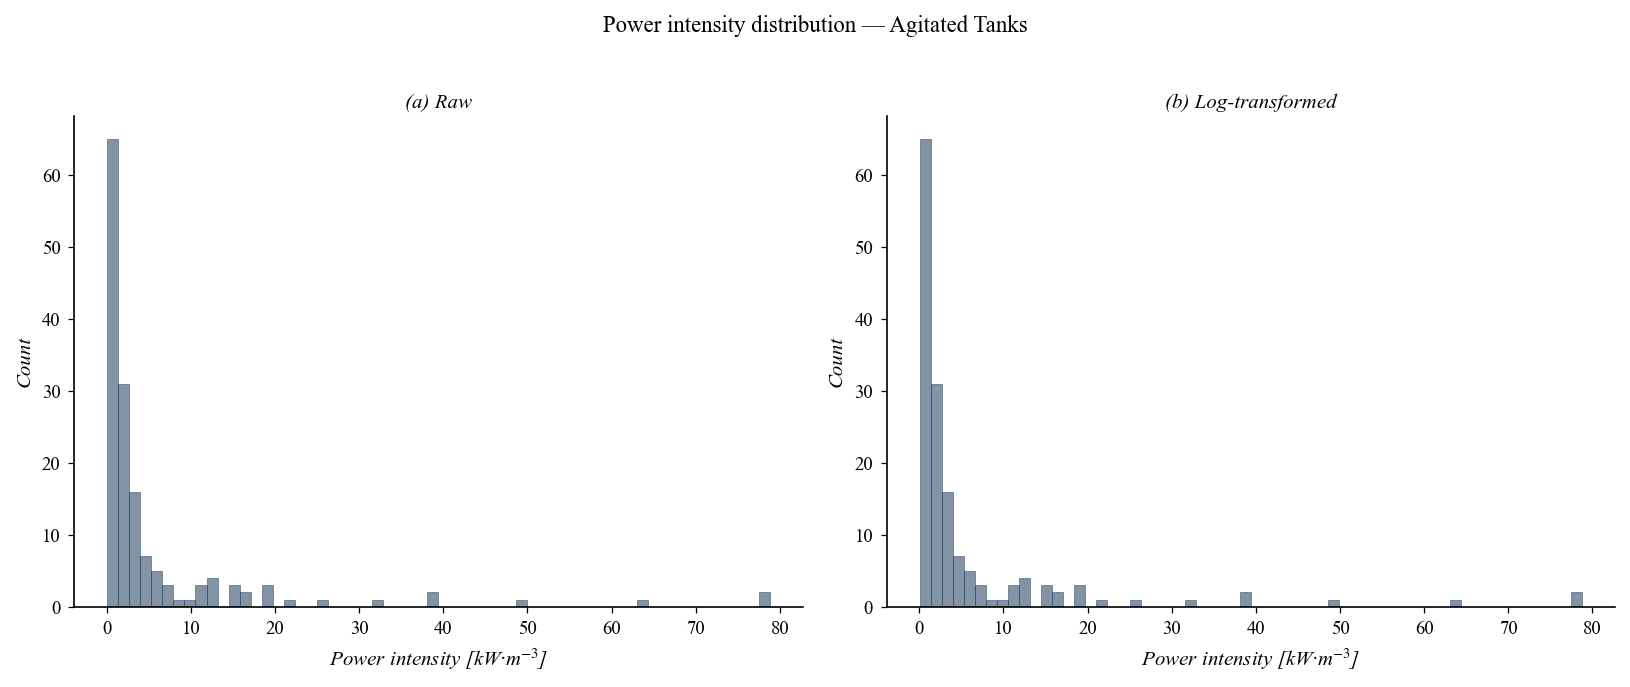

In [6]:
print("generating Figure S1a:\n")
bins = freedman_diaconis_bins(agitated_tanks_raw["PowerToCapacity_kW·m⁻³"])
plot_pv_histogram(agitated_tanks_raw, "PowerToCapacity_kW·m⁻³", "Agitated Tanks", "[kW·m⁻³]" , bins)

generating Figure S1a:



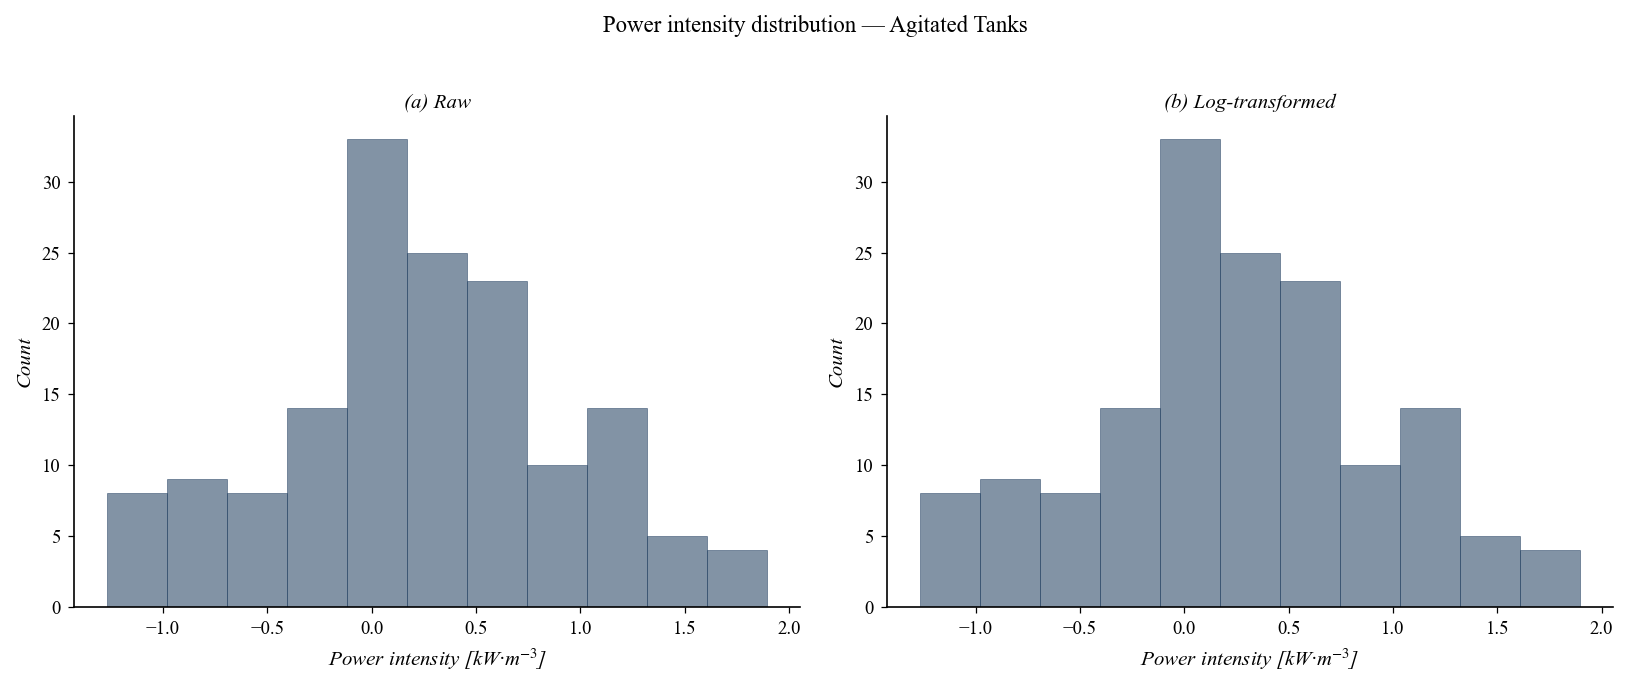

In [7]:
print("generating Figure S1a:\n")
bins = freedman_diaconis_bins(agitated_tanks_raw["log(PowerToCapacity)"])
plot_pv_histogram(agitated_tanks_raw, "log(PowerToCapacity)", "Agitated Tanks", "" , bins)

In [8]:
print("generating Table S1:\n")
distributions_results_at = distribution_kolmogorov_smirnov_tests(agitated_tanks_raw["PowerToCapacity_kW·m⁻³"])
print(distributions_results_at)

generating Table S1:

  Distribution  KS Statistic       p-value
0   Log-normal        0.0685  4.490916e-01
1       Normal        0.3168  3.793267e-14
2   Triangular        0.6713  1.357152e-68
3      Uniform        0.7356  2.582983e-85


### ***1.1.2 Power–Capacity Trends Across Agitated Tanks***

generating Figure S2a:



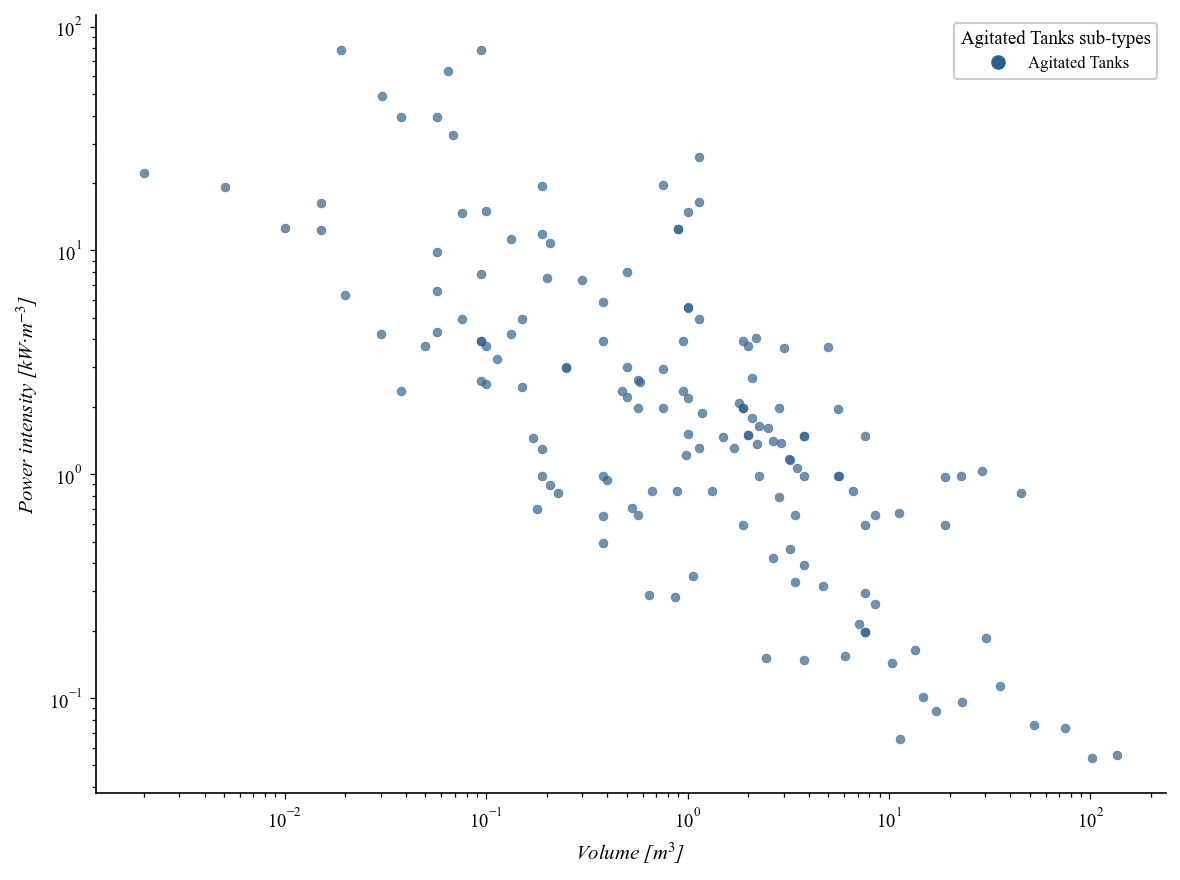

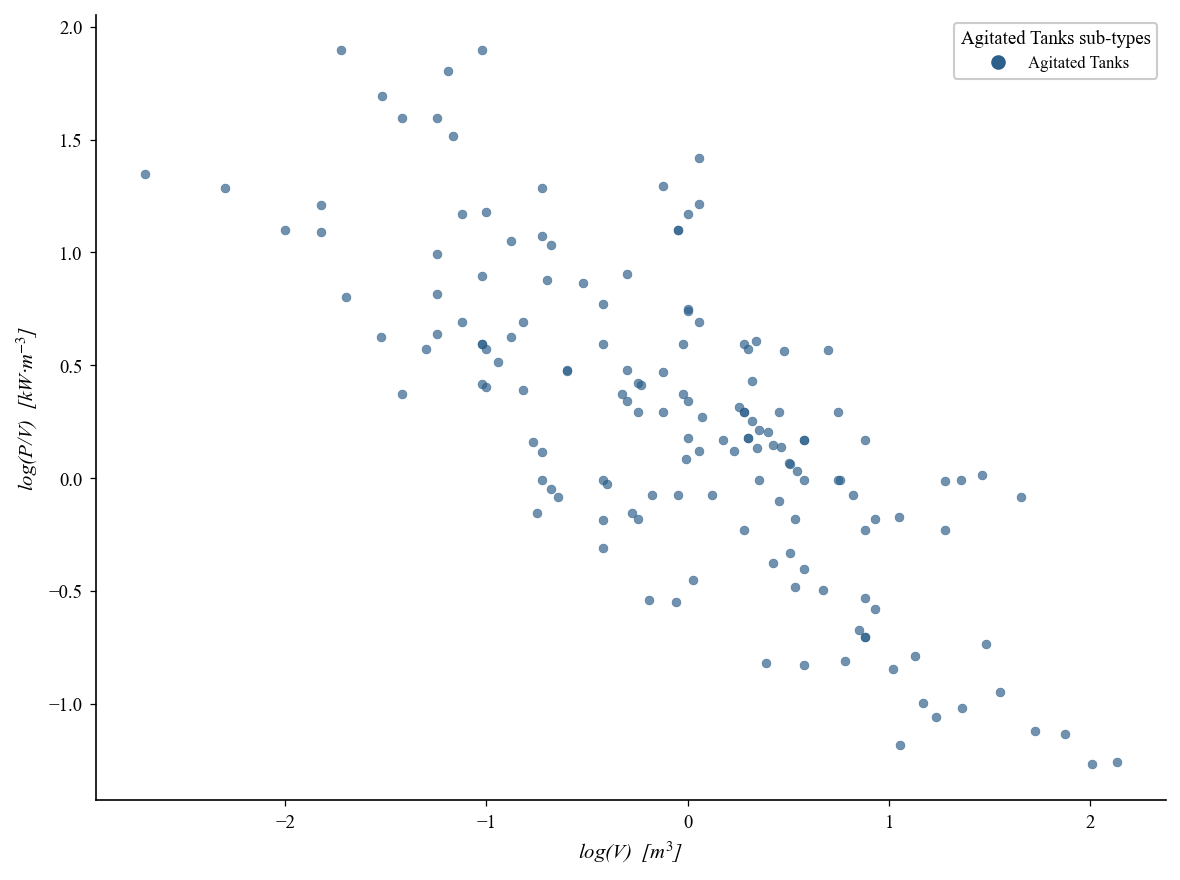

In [9]:
print("generating Figure S2a:\n")
type_color_map = {
    "Agitated Tanks": "#2C5F8A",
}

plot_pv_vs_v_by_type(df=agitated_tanks_raw, type_color_map=type_color_map, equipment_type="Agitated Tanks")
plot_logpv_vs_logv_by_type(df=agitated_tanks_raw, type_color_map=type_color_map, equipment_type="Agitated Tanks")


## ***1.2. Agitated Tanks: Model Selection***

In [10]:
print("generating Table S2:\n")
model_selection_results_at, model_coeffs_at = polynomial_loglog_model_selection(df = agitated_tanks_raw, x_col = "log(Capacity)", y_col = "log(PowerToCapacity)", degrees = [1,2,3])
model_selection_results_at

generating Table S2:



,Degree,R2,R2_adj,RMSE,AIC,BIC,F-stat,Significance_F,Nested_F,Nested_F_p,CI_zero,Eligible
0,1,0.564673,0.561790,0.452414,195.489168,201.550044,195.865485,4.616042e-29,NaN,NaN,none,True
1,2,0.572239,0.566536,0.448465,194.806544,203.897858,100.331562,2.188201e-28,2.6532,0.1054,a2,False
2,3,0.572419,0.563810,0.448371,196.742200,208.863951,66.490629,2.413120e-27,0.0627,0.8027,"a2, a3",False


In [11]:
print("generating Table S3:\n")
model_coeffs_at

generating Table S3:



,Degree,Term,Coefficient,t-stat,p-value,CI Lower,CI Upper,CI_zero
0,1,Intercept,0.231933,6.295009,3.172630e-09,0.159137,0.304730,False
1,1,x^1,-0.567641,-13.995195,4.616042e-29,-0.647778,-0.487503,False
2,2,Intercept,0.275833,6.063907,1.032154e-08,0.185953,0.365712,False
3,2,x^1,-0.580292,-14.125777,2.385546e-29,-0.661463,-0.499121,False
4,2,x^2,-0.053734,-1.628869,1.054391e-01,-0.118916,0.011448,True
5,3,Intercept,0.277345,6.025504,1.264611e-08,0.186392,0.368298,False
6,3,x^1,-0.566896,-8.393641,3.371755e-14,-0.700353,-0.433438,False
7,3,x^2,-0.056605,-1.616210,1.081642e-01,-0.125812,0.012602,True
8,3,x^3,-0.005943,-0.250350,8.026613e-01,-0.052854,0.040967,True


## ***1.3. Agitated Tanks: Handling of Influential Points***

### ***1.3.1 Evaluating Leverages, Externally Studentized Residuals, Difference in Fits, and Cook's Distance***

In [12]:
print("generating Table S5a:\n")
df_influence_at, lev_thresh_at, resid_stud_thresh_at, dffits_thresh_at, cooks_d_thresh_at = influence_measures(df=agitated_tanks_raw, x_col="log(Capacity)", y_col="log(PowerToCapacity)", degree = 1, xcol = "Volume_m³", ycol = "PowerToCapacity_kW·m⁻³", sorted_id_col="Capacity Sorted No.", orig_id_col="Entry_No.")
influential_points_at = df_influence_at[(df_influence_at["High_StudResid"] == True) | (df_influence_at["High_DFFITS"] == True) |(df_influence_at["High_Cooks"] == True)].copy()
influential_points_at["Type"] = "Agitated Tanks"
influential_points_at

generating Table S5a:



,Capacity Sorted No.,Entry_No.,Volume_m³,PowerToCapacity_kW·m⁻³,log(Capacity),log(PowerToCapacity),y_pred,Leverage,High_Leverage,StudResid,High_StudResid,DFFITS,High_DFFITS,CooksD,High_Cooks,Type
0,1,147,0.002006,22.301116,-2.697611,1.348327,1.763207,0.062780,True,-0.940683,False,-0.243464,False,0.029660,True,Agitated Tanks
5,6,36,0.018927,78.797277,-1.722917,1.896511,1.209931,0.029141,False,1.536986,False,0.266282,False,0.035136,True,Agitated Tanks
16,17,83,0.064352,63.733092,-1.191438,1.804365,0.908242,0.017148,False,2.004600,False,0.264781,False,0.034367,True,Agitated Tanks
22,23,30,0.094635,78.797277,-1.023947,1.896511,0.813167,0.014297,False,2.434860,False,0.293239,True,0.041636,True,Agitated Tanks
137,138,40,11.356230,0.065664,1.055234,-1.182670,-0.367060,0.015961,False,-1.819193,False,-0.231689,False,0.026436,True,Agitated Tanks
148,149,115,45.000954,0.822241,1.653222,-0.085001,-0.706502,0.029139,False,1.389325,False,0.240692,False,0.028789,True,Agitated Tanks


### ***1.3.2 Visualization of Observations w/ Flagged Influential Points***

generating Figure S3:



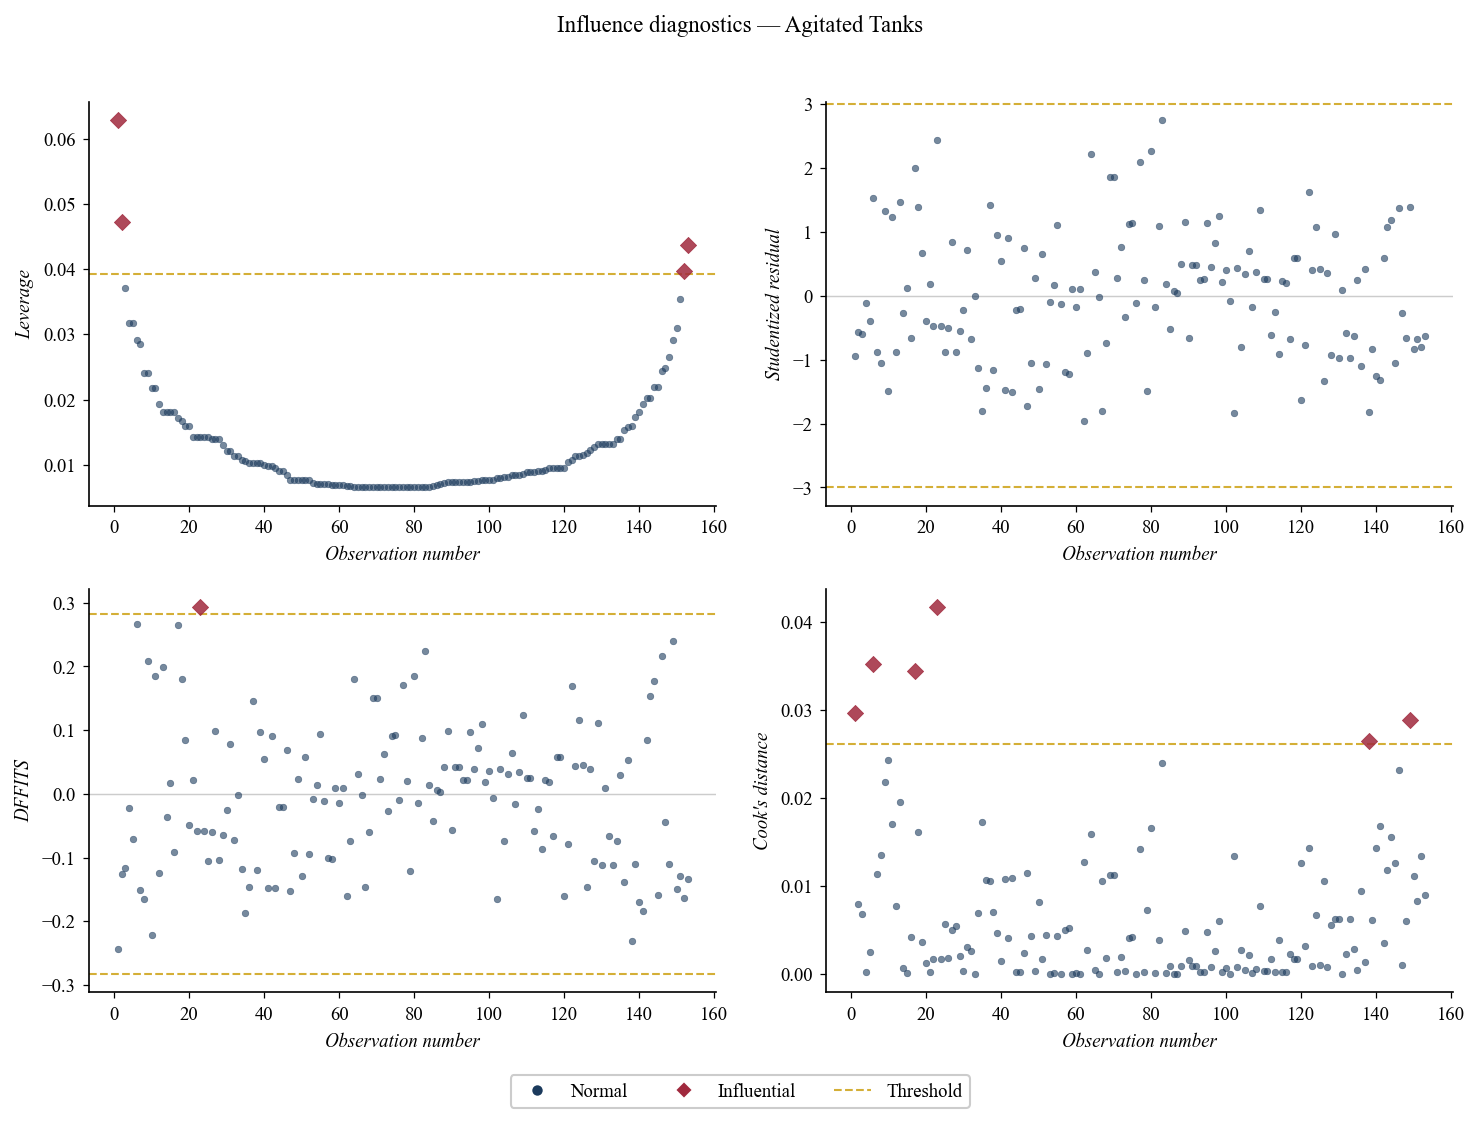

In [13]:
print("generating Figure S3:\n")
plot_leverage(df_influence_at, equipment_type = "Agitated Tanks", id_col="Capacity Sorted No.", mean_lev=None)


## ***1.4. Agitated Tanks: Regression (w/o and w/ Removed Outliers)***

### ***1.4.1 Before Outlier Removal***

In [14]:
selected_model_at, selected_model_coeffs_at = polynomial_loglog_model_selection(df = agitated_tanks_raw, x_col = "log(Capacity)", y_col = "log(PowerToCapacity)", degrees = [1])
selected_model_at
selected_model_coeffs_at

,Degree,Term,Coefficient,t-stat,p-value,CI Lower,CI Upper,CI_zero
0,1,Intercept,0.231933,6.295009,3.172630e-09,0.159137,0.304730,False
1,1,x^1,-0.567641,-13.995195,4.616042e-29,-0.647778,-0.487503,False


generating Figure S19a:



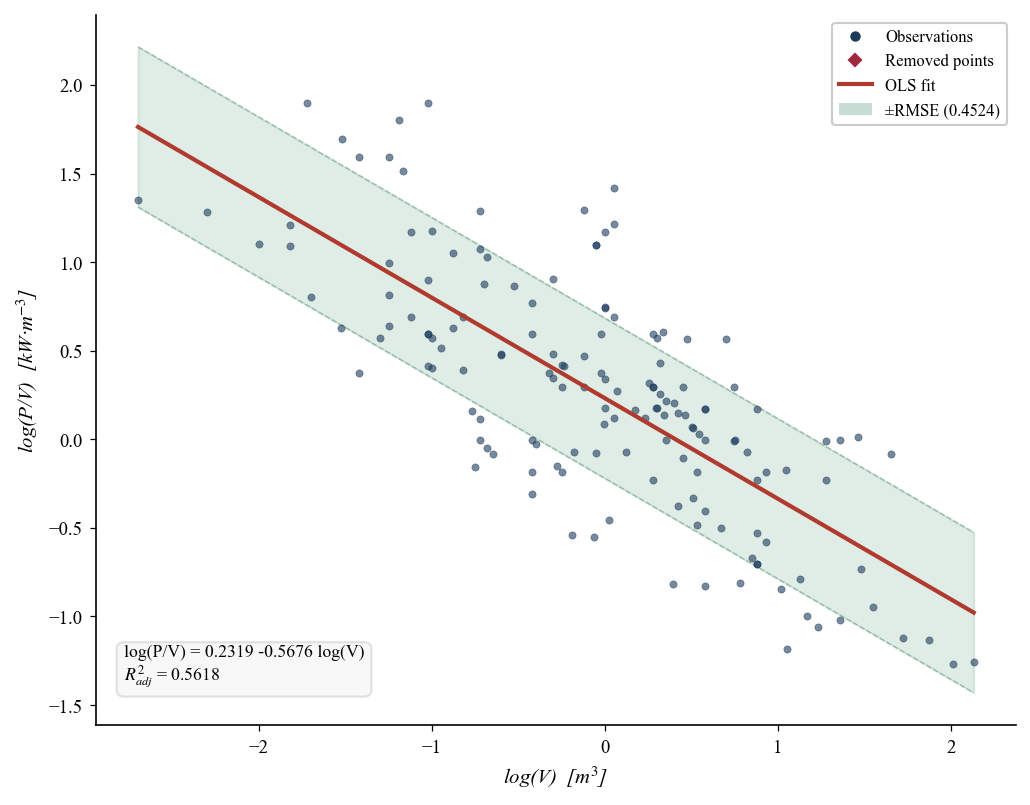

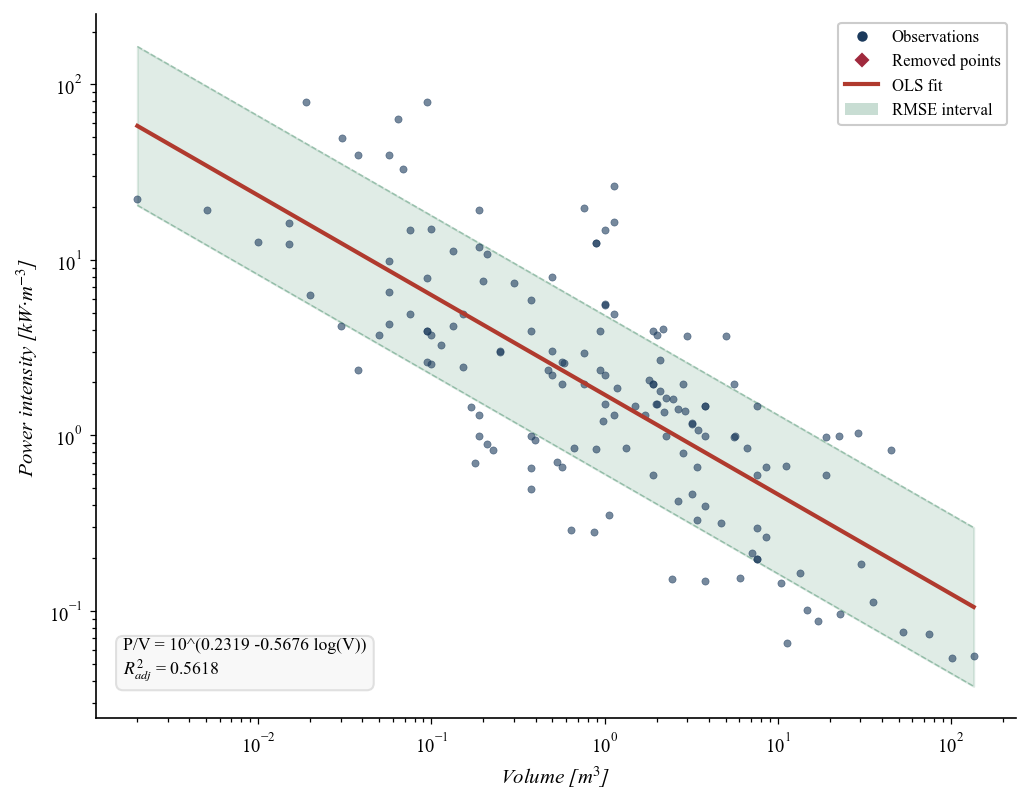

In [15]:
print("generating Figure S19a:\n")
plot_fit_unified(df=agitated_tanks_raw, x_col="log(Capacity)", y_col="log(PowerToCapacity)", df_coefs=selected_model_coeffs_at, df_model=selected_model_at, equipment_type="Agitated Tanks", loglog=True)
plot_fit_unified(df=agitated_tanks_raw, x_col="Volume_m³", y_col="PowerToCapacity_kW·m⁻³", df_coefs=selected_model_coeffs_at, df_model=selected_model_at, equipment_type="Agitated Tanks", loglog=False)

### ***1.4.2 After Outlier Removal***

In [16]:
agitated_tanks_clean = agitated_tanks_raw[~agitated_tanks_raw["Entry_No."].isin(influential_points_at["Entry_No."])].reset_index(drop = True)
agitated_tanks_clean.head()

,Capacity Sorted No.,Entry_No.,Type,Volume_m³,Power_kW,PowerToCapacity_kW·m⁻³,log(Capacity),log(PowerToCapacity)
0,2,148,Agitated Tanks,0.005035,0.096941,19.254974,-2.298035,1.284543
1,3,149,Agitated Tanks,0.010031,0.126769,12.637299,-1.998641,1.101654
2,4,37,Agitated Tanks,0.015142,0.246081,16.251938,-1.819827,1.210905
3,5,86,Agitated Tanks,0.015142,0.186425,12.312075,-1.819827,1.090331
4,7,150,Agitated Tanks,0.020025,0.126769,6.330594,-1.698431,0.801444


In [17]:
print("generating Table S9:\n")
selected_model_at, selected_model_coeffs_at = polynomial_loglog_model_selection(df = agitated_tanks_clean, x_col = "log(Capacity)", y_col = "log(PowerToCapacity)", degrees = [1])
selected_model_at
selected_model_coeffs_at

generating Table S9:



,Degree,Term,Coefficient,t-stat,p-value,CI Lower,CI Upper,CI_zero
0,1,Intercept,0.218118,6.063665,1.098310e-08,0.147022,0.289214,False
1,1,x^1,-0.548910,-13.181726,1.406352e-26,-0.631214,-0.466607,False


In [75]:
print("generating Table S10:\n")
x = agitated_tanks_clean["log(Capacity)"].values
y = agitated_tanks_clean["log(PowerToCapacity)"].values

degree = 1   

X_poly = np.vander(x, degree + 1, increasing=True)  

# Fit OLS regression
ols_model = sm.OLS(y, X_poly).fit()

# Classic OLS summary
print(f"=== Standard OLS (Polynomial degree = {degree}) Results ===")
print(ols_model.summary())

# Robust (HC3) standard errors
robust_model = ols_model.get_robustcov_results(cov_type="HC3")
print(f"\n=== Robust (HC3) Results for degree = {degree} ===")
print(robust_model.summary())

generating Table S10:

=== Standard OLS (Polynomial degree = 1) Results ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     173.8
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.41e-26
Time:                        15:01:25   Log-Likelihood:                -85.585
No. Observations:                 147   AIC:                             175.2
Df Residuals:                     145   BIC:                             181.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

generating Figure S19b:



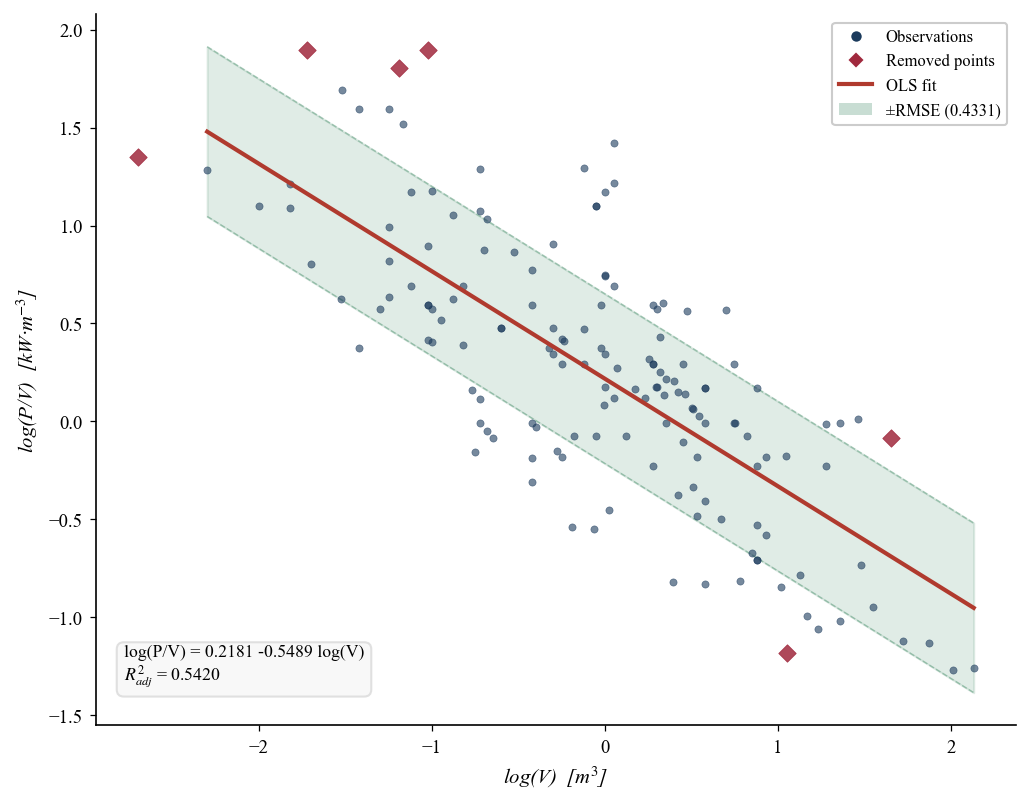

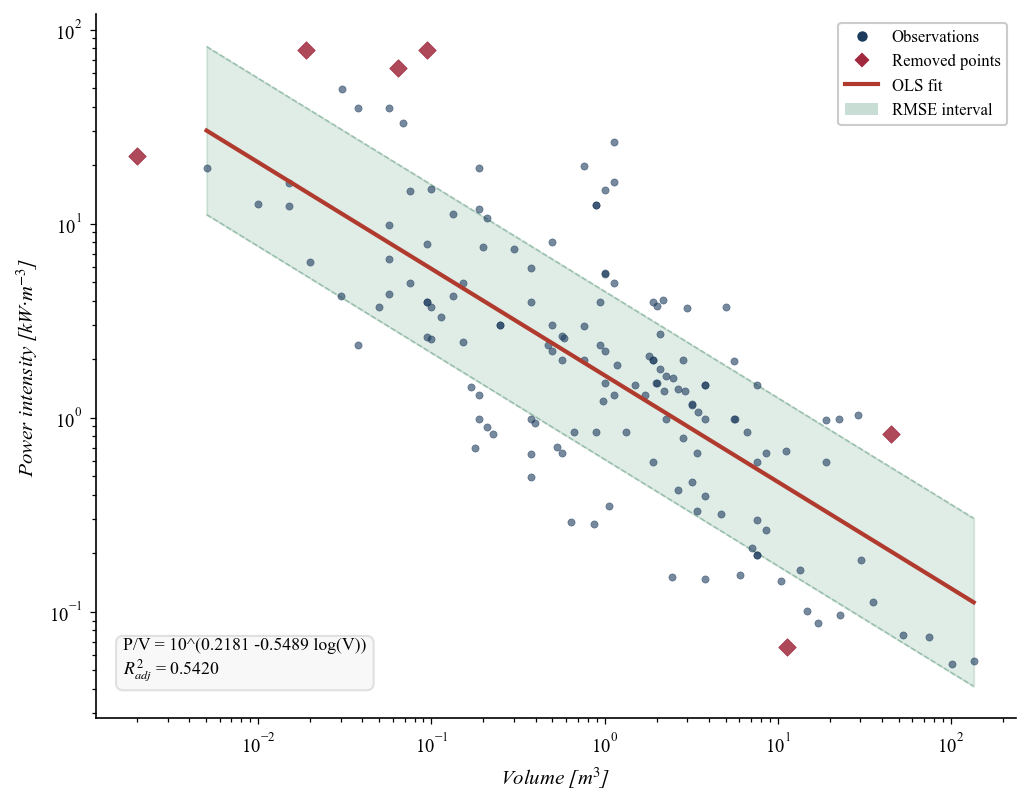

In [76]:
print("generating Figure S19b:\n")
plot_fit_unified(df=agitated_tanks_clean, x_col="log(Capacity)", y_col="log(PowerToCapacity)", df_coefs=selected_model_coeffs_at, df_model=selected_model_at, loglog=True, equipment_type="Agitated Tanks", df_influential=influential_points_at)
plot_fit_unified(df=agitated_tanks_clean, x_col="Volume_m³", y_col="PowerToCapacity_kW·m⁻³", df_coefs=selected_model_coeffs_at, df_model=selected_model_at, loglog=False, equipment_type="Agitated Tanks", df_influential=influential_points_at)

generating Figure S39 and Table S20:



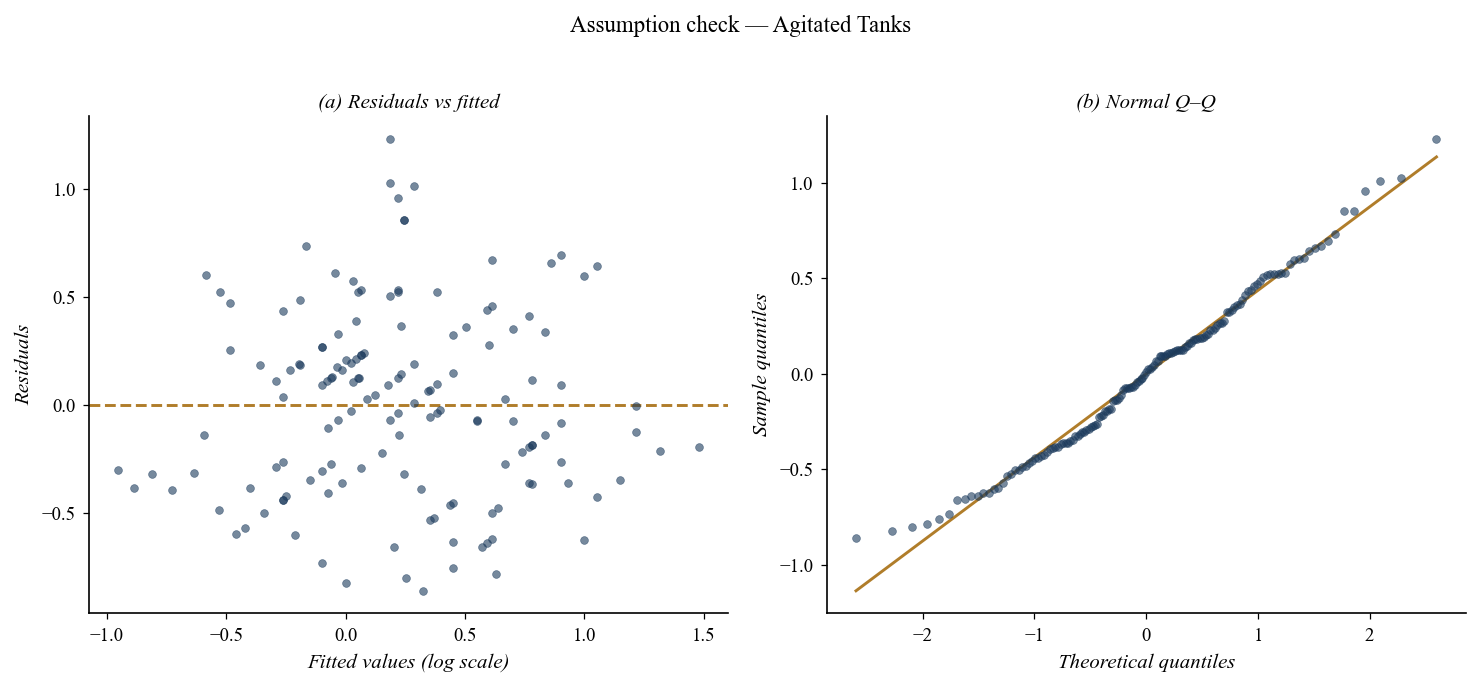

Kolmogorov–Smirnov Test (Normality):
  Statistic = 0.0623, p-value = 0.5955
  ✅ Residuals appear normal.

Breusch-Pagan Test (Heteroscedasticity):
  LM-statistic = 0.0404, p-value = 0.8408
  ✅ No evidence of heteroscedasticity.


In [77]:
print("generating Figure S39 and Table S20:\n")
model_at = regression_diagnostics(x_log = agitated_tanks_clean["log(Capacity)"].values, y_log = agitated_tanks_clean["log(PowerToCapacity)"].values, equipment_type = "Agitated Tanks", degree=1)

## ***1.4.4 — Piccinno Comparison and Agitator RPM***

generating Figure 3:



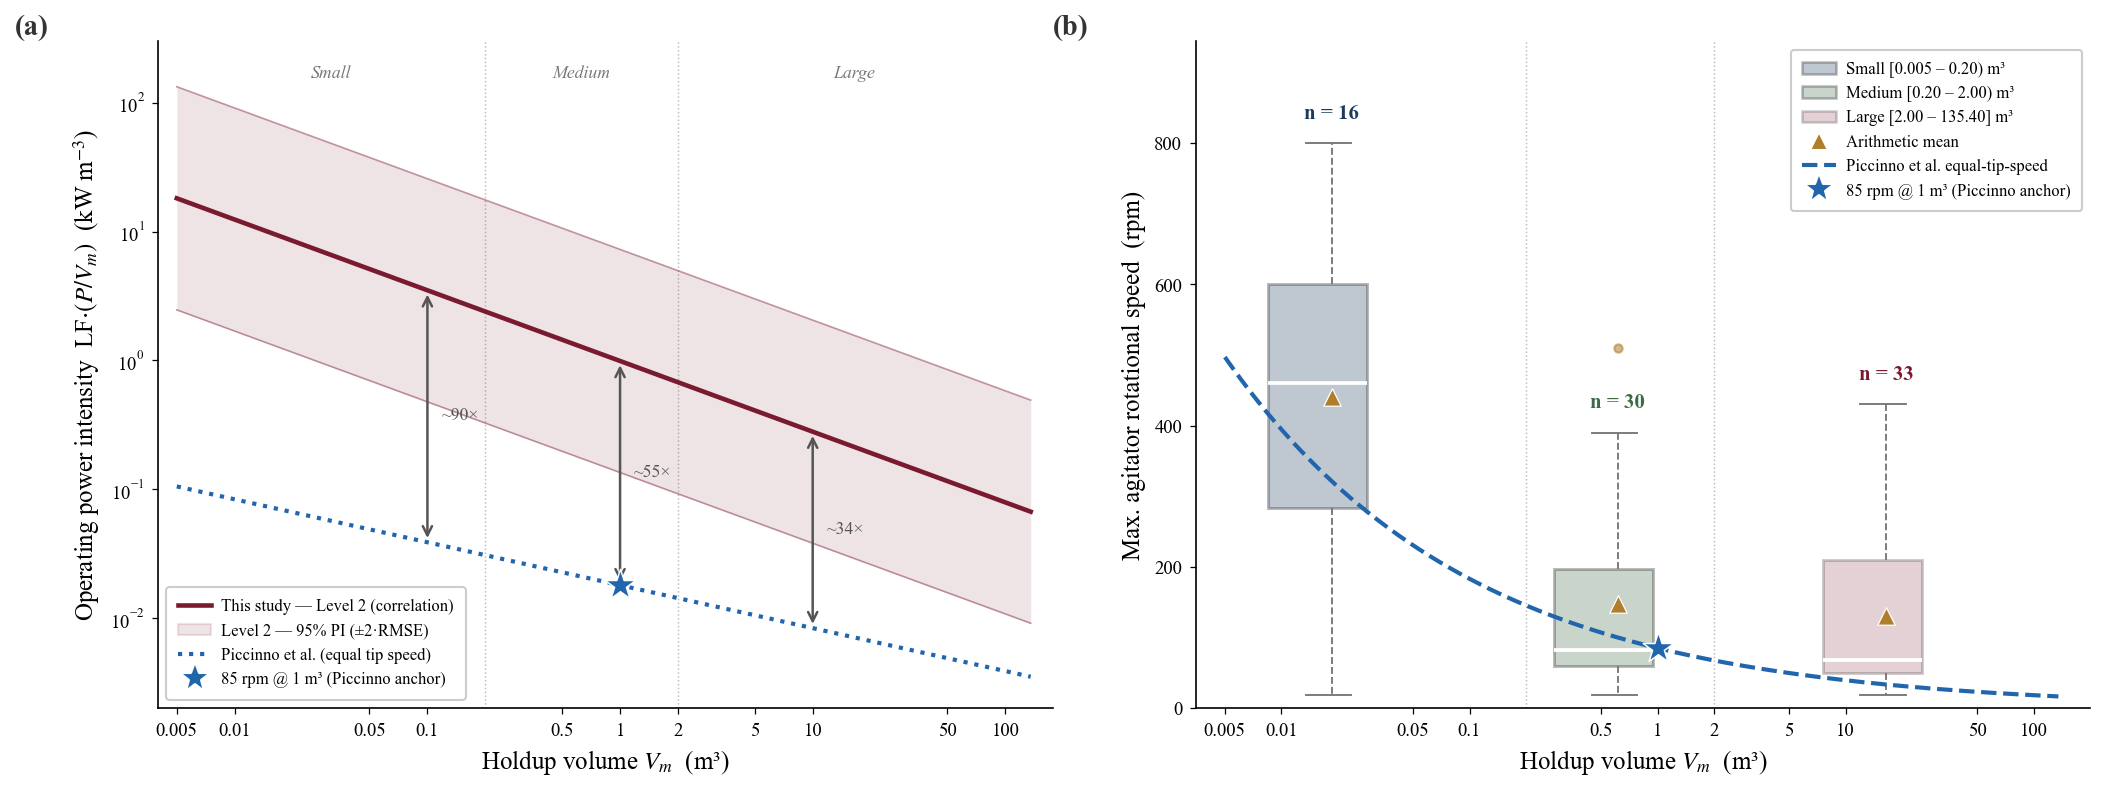

In [78]:
print("generating Figure 3:\n")

import matplotlib.transforms as mtransforms

LF = 0.60
VMIN, VMAX = 0.005, 135.4

def L2_op(V):  return LF * 10**0.2181 * np.asarray(V)**(-0.5489)
RMSE_LOG  = 0.4331
PI_FACTOR = 10**(2 * RMSE_LOG)
def L2_lo(V): return L2_op(V) / PI_FACTOR
def L2_hi(V): return L2_op(V) * PI_FACTOR
def picc_pv(V):  return 0.018006 * np.asarray(V)**(-1.0/3.0)
def picc_rpm(V): return 85.0    * np.asarray(V)**(-1.0/3.0)

C_L2              = "#7A1A2E"
C_PICC            = "#2166AC"
MEAN_MARKER_COLOR = "#B07D2A"
CAP_FACE  = {"Small": "#1B3A5C", "Medium": "#3D6B45", "Large": "#7A1A2E"}
CAP_ALPHA = {"Small": 0.28,      "Medium": 0.28,      "Large": 0.20}

BIN_DEFS = [
    ("Small",  0.0,  0.20,  False),   # [0.005, 0.20)
    ("Medium", 0.20,   2.00,  False),   # [0.20,  2.00)
    ("Large",  2.00,   136, True),    # [2.00,  135.4]
]


def _panel_a(ax):
    ax.set_xscale("log"); ax.set_yscale("log")
    Vgrid = np.logspace(np.log10(VMIN), np.log10(VMAX), 400)

    ax.plot(Vgrid, picc_pv(Vgrid), color=C_PICC, lw=2.0, ls=":", zorder=4)
    ax.scatter([1.0], [picc_pv(1.0)], marker="*", s=240, color=C_PICC,
               edgecolors="white", linewidths=0.7, zorder=6)

    ax.fill_between(Vgrid, L2_lo(Vgrid), L2_hi(Vgrid),
                    color=C_L2, alpha=0.12, linewidth=0, zorder=1)
    ax.plot(Vgrid, L2_lo(Vgrid), color=C_L2, lw=0.8, alpha=0.45, zorder=2)
    ax.plot(Vgrid, L2_hi(Vgrid), color=C_L2, lw=0.8, alpha=0.45, zorder=2)
    ax.plot(Vgrid, L2_op(Vgrid), color=C_L2, lw=2.2, ls="-", zorder=4)

    for Vg in (0.1, 1.0, 10.0):
        y_hi, y_lo = L2_op(Vg), picc_pv(Vg)
        ax.annotate("", xy=(Vg, y_hi), xytext=(Vg, y_lo),
                    arrowprops=dict(arrowstyle="<->", color="#555555", lw=1.2), zorder=5)
        ax.text(Vg * 1.18, np.sqrt(y_hi * y_lo), f"~{y_hi / y_lo:.0f}\u00d7",
                ha="left", va="center", fontsize=8.5, color="#555555", zorder=6)

    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    for xb in (0.2, 2.0):
        ax.axvline(xb, color="#BBBBBB", lw=0.7, ls=":", zorder=0)
    for xc, lab in [(np.sqrt(VMIN * 0.2),  "Small"),
                    (np.sqrt(0.2 * 2.0),   "Medium"),
                    (np.sqrt(2.0 * VMAX),  "Large")]:
        ax.text(xc, 0.965, lab, ha="center", va="top", transform=trans,
                fontsize=8.5, style="italic", color="#777777")

    ax.set_xlabel("Holdup volume $V_m$  (m\u00b3)", fontsize=12)
    ax.set_ylabel(r"Operating power intensity  LF$\cdot(P/V_m)$  (kW m$^{-3}$)", fontsize=12)
    ax.set_xlim(VMIN * 0.8, VMAX * 1.3); ax.set_ylim(2e-3, 3e2)
    xticks = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
    ax.set_xticks(xticks)
    ax.set_xticklabels(["%g" % t for t in xticks], fontsize=9)
    ax.minorticks_off()
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    handles = [
        Line2D([0],[0], color=C_L2, lw=2.2,
               label="This study \u2014 Level 2 (correlation)"),
        Patch(facecolor=C_L2, alpha=0.12, edgecolor=C_L2,
              label="Level 2 \u2014 95% PI (\u00b12\u00b7RMSE)"),
        Line2D([0],[0], color=C_PICC, lw=2.0, ls=":",
               label="Piccinno et al. (equal tip speed)"),
        Line2D([0],[0], marker="*", color="w", markerfacecolor=C_PICC,
               markeredgecolor="white", markersize=15,
               label="85 rpm @ 1 m\u00b3 (Piccinno anchor)"),
    ]
    ax.legend(handles=handles, fontsize=8, frameon=True, facecolor="white",
              edgecolor="#cccccc", framealpha=1.0, loc="lower left",
              handletextpad=0.6, borderpad=0.7, labelspacing=0.5)
    ax.annotate("(a)", xy=(-0.16, 1.04), xycoords="axes fraction",
                ha="left", va="top", fontsize=14, fontweight="bold", color="#333333")


def _panel_b(ax):
    _rpm_col = "Max Shaft Rotational Speed, rpm"
    _raw_df  = pd.read_excel("Equipment Capacity Power Type Input File.xlsx",
                              sheet_name="Agitated Tanks")

    if _rpm_col not in _raw_df.columns:
        ax.text(0.5, 0.5, "rpm data not available in this workbook copy",
                ha="center", va="center", transform=ax.transAxes,
                color="#888888", fontsize=11, style="italic")
        return

    # Build a clean vol–rpm frame from the raw sorted frame
    df_rpm = pd.DataFrame({
        "vol": agitated_tanks_raw["Volume_m\u00b3"].values,
        "rpm": pd.to_numeric(
            _raw_df.sort_values("Tank Rated Volume, gal")
                   .reset_index(drop=True)[_rpm_col],
            errors="coerce"
        ).values
    }).dropna(subset=["rpm"])
    df_rpm = df_rpm[(df_rpm["vol"] > 0) & (df_rpm["rpm"] > 0)].copy()

    groups, box_x, ns, classes = [], [], [], []
    for cls, lo, hi, closed_hi in BIN_DEFS:
        hi_filter = (df_rpm["vol"] <= hi) if closed_hi else (df_rpm["vol"] < hi)
        sub = df_rpm[(df_rpm["vol"] >= lo) & hi_filter]
        if len(sub) == 0:
            continue
        groups.append(sub["rpm"].values)
        ns.append(len(sub))
        classes.append(cls)
        box_x.append(np.sqrt(sub["vol"].min() * sub["vol"].max()))

    ax.set_xscale("log")
    log_hw = 0.225
    widths = [10**(np.log10(x) + log_hw) - 10**(np.log10(x) - log_hw) for x in box_x]

    bp = ax.boxplot(groups, positions=box_x, widths=widths, patch_artist=True,
                    manage_ticks=False,
                    medianprops=dict(color="#FFFFFF", linewidth=1.8),
                    whiskerprops=dict(linewidth=0.9, linestyle="--", color="#777777"),
                    capprops=dict(linewidth=0.9, color="#777777"),
                    flierprops=dict(marker="o", markersize=4, alpha=0.55,
                                    markerfacecolor=MEAN_MARKER_COLOR,
                                    markeredgecolor=MEAN_MARKER_COLOR, linewidth=0))
    for patch, cls in zip(bp["boxes"], classes):
        patch.set_facecolor(CAP_FACE[cls]); patch.set_alpha(CAP_ALPHA[cls])
        patch.set_edgecolor("black"); patch.set_linewidth(1.4)

    for x, vals in zip(box_x, groups):
        ax.scatter(x, np.mean(vals), color=MEAN_MARKER_COLOR, marker="^",
                   s=70, zorder=6, edgecolors="white", linewidths=0.6)

    Vgrid = np.logspace(np.log10(VMIN), np.log10(VMAX), 400)
    ax.plot(Vgrid, picc_rpm(Vgrid), color=C_PICC, lw=2.0, ls="--", zorder=3)
    ax.scatter([1.0], [85.0], marker="*", s=240, color=C_PICC,
               edgecolors="white", linewidths=0.7, zorder=7)

    ymax = df_rpm["rpm"].max()
    def whisker_top(vals):
        q1, q3 = np.percentile(vals, [25, 75])
        fence = q3 + 1.5 * (q3 - q1)
        inside = vals[vals <= fence]
        return inside.max() if len(inside) else vals.max()

    for x, cls, n, vals in zip(box_x, classes, ns, groups):
        ax.text(x, whisker_top(vals) + 0.035 * ymax, f"n = {n}",
                ha="center", va="bottom", fontsize=10,
                fontweight="bold", color=CAP_FACE[cls])

    for xb in (0.2, 2.0):
        ax.axvline(xb, color="#BBBBBB", lw=0.7, ls=":", zorder=0)

    ax.set_xlabel("Holdup volume $V_m$  (m\u00b3)", fontsize=12)
    ax.set_ylabel("Max. agitator rotational speed  (rpm)", fontsize=12)
    ax.set_xlim(0.0035, 200); ax.set_ylim(0, ymax * 1.18)
    xticks = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
    ax.set_xticks(xticks)
    ax.set_xticklabels(["%g" % t for t in xticks], fontsize=9)
    ax.minorticks_off()
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    legend_els = [
        Patch(facecolor=CAP_FACE["Small"], alpha=CAP_ALPHA["Small"],
              edgecolor="black", linewidth=1.2,
              label="Small [0.005 \u2013 0.20) m\u00b3"),
        Patch(facecolor=CAP_FACE["Medium"], alpha=CAP_ALPHA["Medium"],
              edgecolor="black", linewidth=1.2,
              label="Medium [0.20 \u2013 2.00) m\u00b3"),
        Patch(facecolor=CAP_FACE["Large"], alpha=CAP_ALPHA["Large"],
              edgecolor="black", linewidth=1.2,
              label="Large [2.00 \u2013 135.40] m\u00b3"),
        Line2D([0],[0], marker="^", color="w", markerfacecolor=MEAN_MARKER_COLOR,
               markeredgecolor="white", markersize=9, label="Arithmetic mean"),
        Line2D([0],[0], color=C_PICC, lw=2.0, ls="--",
               label="Piccinno et al. equal-tip-speed"),
        Line2D([0],[0], marker="*", color="w", markerfacecolor=C_PICC,
               markeredgecolor="white", markersize=15,
               label="85 rpm @ 1 m\u00b3 (Piccinno anchor)"),
    ]
    ax.legend(handles=legend_els, fontsize=8, frameon=True, facecolor="white",
              edgecolor="#cccccc", framealpha=1.0, loc="upper right",
              handletextpad=0.6, borderpad=0.7, labelspacing=0.5)
    ax.annotate("(b)", xy=(-0.16, 1.04), xycoords="axes fraction",
                ha="left", va="top", fontsize=14, fontweight="bold", color="#333333")


fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.4))
_panel_a(axL)
_panel_b(axR)
plt.tight_layout()
plt.show()

## ***1.5. Agitated Tanks: Grouping Analysis***

### ***1.5.1 Grouping for all agitated tanks***

In [79]:
min_group_size = 30
min_avg_difference = 2

for num_groups in [3]:
    print(f"\nTesting {num_groups} groups with ≥{min_avg_difference} average difference and ≥{min_group_size} points each:")
    total_found = test_grouping_gm(agitated_tanks_clean["PowerToCapacity_kW·m⁻³"].tolist(), num_groups, min_avg_difference, min_group_size=min_group_size)
    print(f"\n🔢 Total valid groupings found: {total_found}")


Testing 3 groups with ≥2 average difference and ≥30 points each:
Valid grouping #1 (geo mean):
Splits: (0, 30, 60, 147)
Group sizes: [30, 30, 87]
Geometric means: ['7.2785', '2.2077', '0.9152']
Ratios: ['3.30x', '2.41x']
------------------------------------------------------------
Valid grouping #2 (geo mean):
Splits: (0, 30, 61, 147)
Group sizes: [30, 31, 86]
Geometric means: ['7.2785', '2.2286', '0.9028']
Ratios: ['3.27x', '2.47x']
------------------------------------------------------------
Valid grouping #3 (geo mean):
Splits: (0, 30, 62, 147)
Group sizes: [30, 32, 85]
Geometric means: ['7.2785', '2.2200', '0.8946']
Ratios: ['3.28x', '2.48x']
------------------------------------------------------------
Valid grouping #4 (geo mean):
Splits: (0, 30, 63, 147)
Group sizes: [30, 33, 84]
Geometric means: ['7.2785', '2.0856', '0.9069']
Ratios: ['3.49x', '2.30x']
------------------------------------------------------------
Valid grouping #5 (geo mean):
Splits: (0, 30, 64, 147)
Group sizes

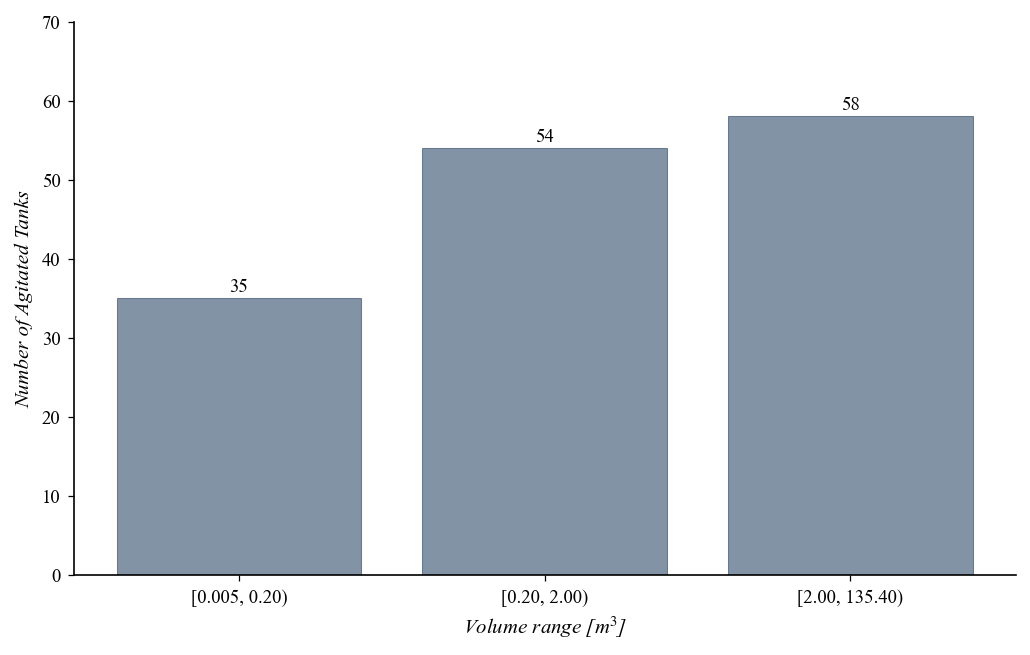

In [80]:
splits_at = [35, 54, 58]
bin_labels_at = ["[0.005, 0.20)", "[0.20, 2.00)", "[2.00, 135.40)"]
plot_capacity_distribution(bin_labels = bin_labels_at, counts = splits_at , capacity_unit="Volume_m³", equipment_type="Agitated Tanks")

generating Figure S35a:



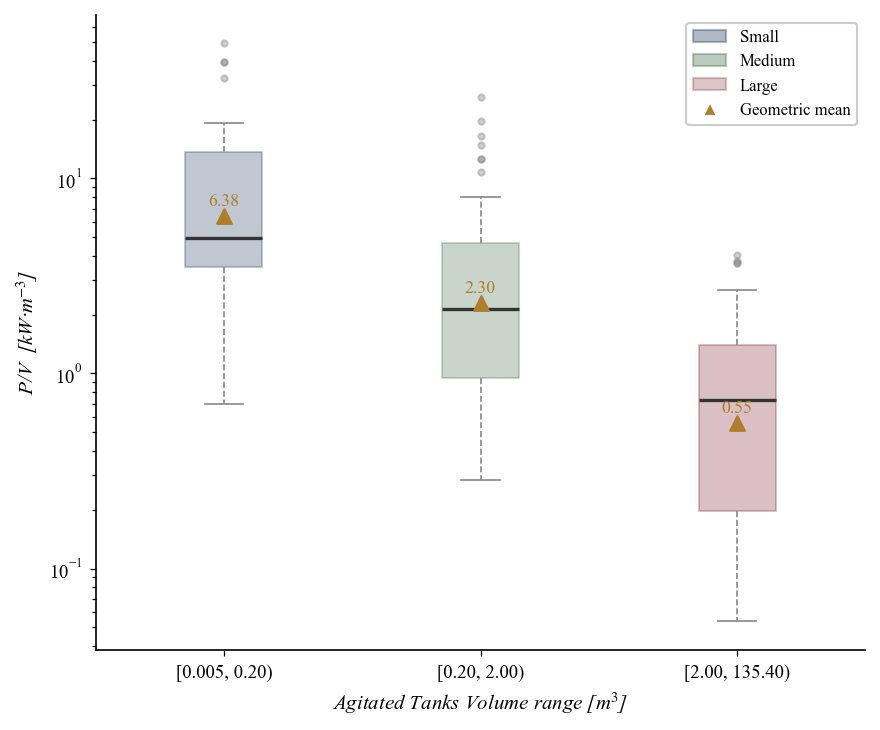

In [81]:
print("generating Figure S35a:\n")
plot_power_to_capacity_boxplot(df=agitated_tanks_clean, y_col="PowerToCapacity_kW·m⁻³", splits=splits_at, bin_labels=bin_labels_at, capacity_unit="Volume_m³", equipment_type="Agitated Tanks")

In [82]:
print("generating Table S16:\n")
labels = {"Group 1": "Small", "Group 2": "Medium", "Group 3": "Large"}
results = anova_tukey(y = agitated_tanks_clean["log(PowerToCapacity)"], splits = splits_at, group_labels = labels)

print("ANOVA Results:")
display(results["ANOVA"])     

print("\nTukey HSD Results:")
display(results["Tukey_standard"])

print("\nLog-space-adjusted Tukey HSD (geometric means):")
display(results["Tukey_table"])   

generating Table S16:

ANOVA Results:


,F-statistic,p-value,Significant (α=0.05)
0,54.742276,2.077742e-18,True



Tukey HSD Results:


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Small,Medium,-0.4438,0.0001,-0.6952,-0.1925,True
1,Small,Large,-1.0608,0.0000,-1.3087,-0.8129,True
2,Medium,Large,-0.6170,0.0000,-0.8360,-0.3980,True



Log-space-adjusted Tukey HSD (geometric means):


,group1,group2,GM group1,GM group2,GM ratio,Lower 95% CI,Upper 95% CI,p-adj,Significant (α=0.05)
0,Small,Medium,6.381785,2.296705,0.359915,0.201744,0.641948,0.0001,True
1,Small,Large,6.381785,0.554770,0.086936,0.049125,0.153851,0.0000,True
2,Medium,Large,2.296705,0.554770,0.241546,0.145881,0.399945,0.0000,True


Group 1: n=35, bins=8


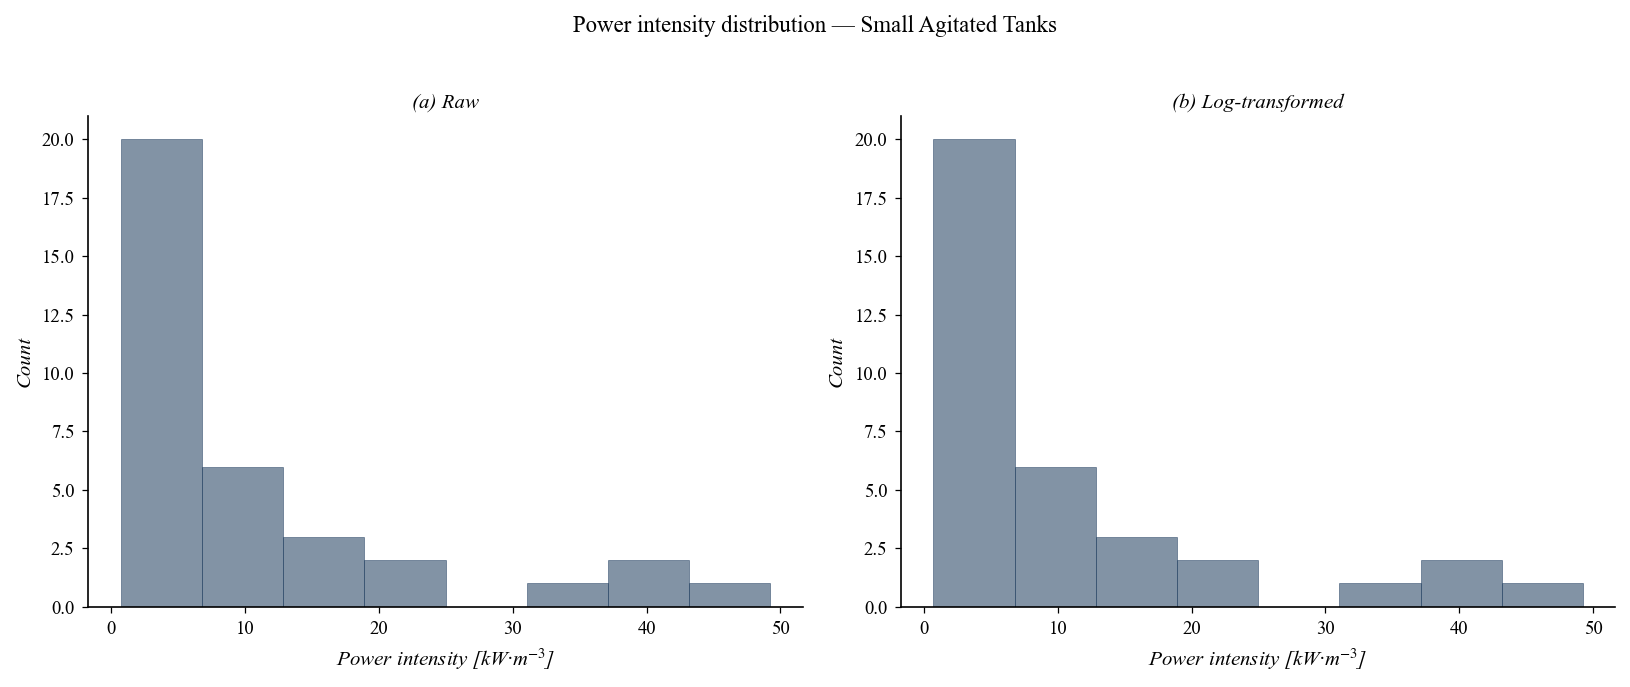

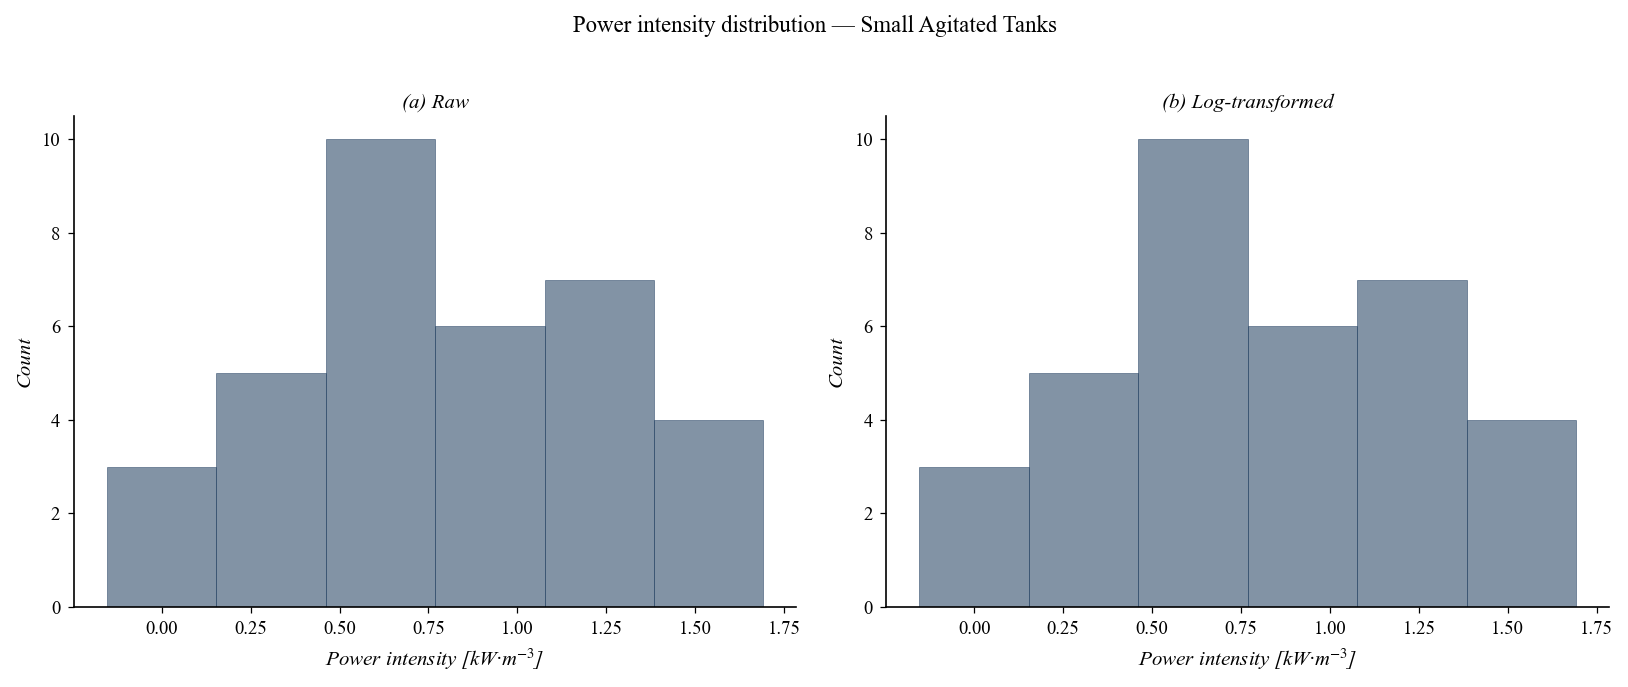


Kolmogorov–Smirnov Test Results for Group 1:
  Distribution  KS Statistic       p-value
0   Log-normal        0.0946  8.838013e-01
1       Normal        0.2120  7.369747e-02
2   Triangular        0.3547  1.906183e-04
3      Uniform        0.5082  6.626304e-09 

Group 2: n=54, bins=14


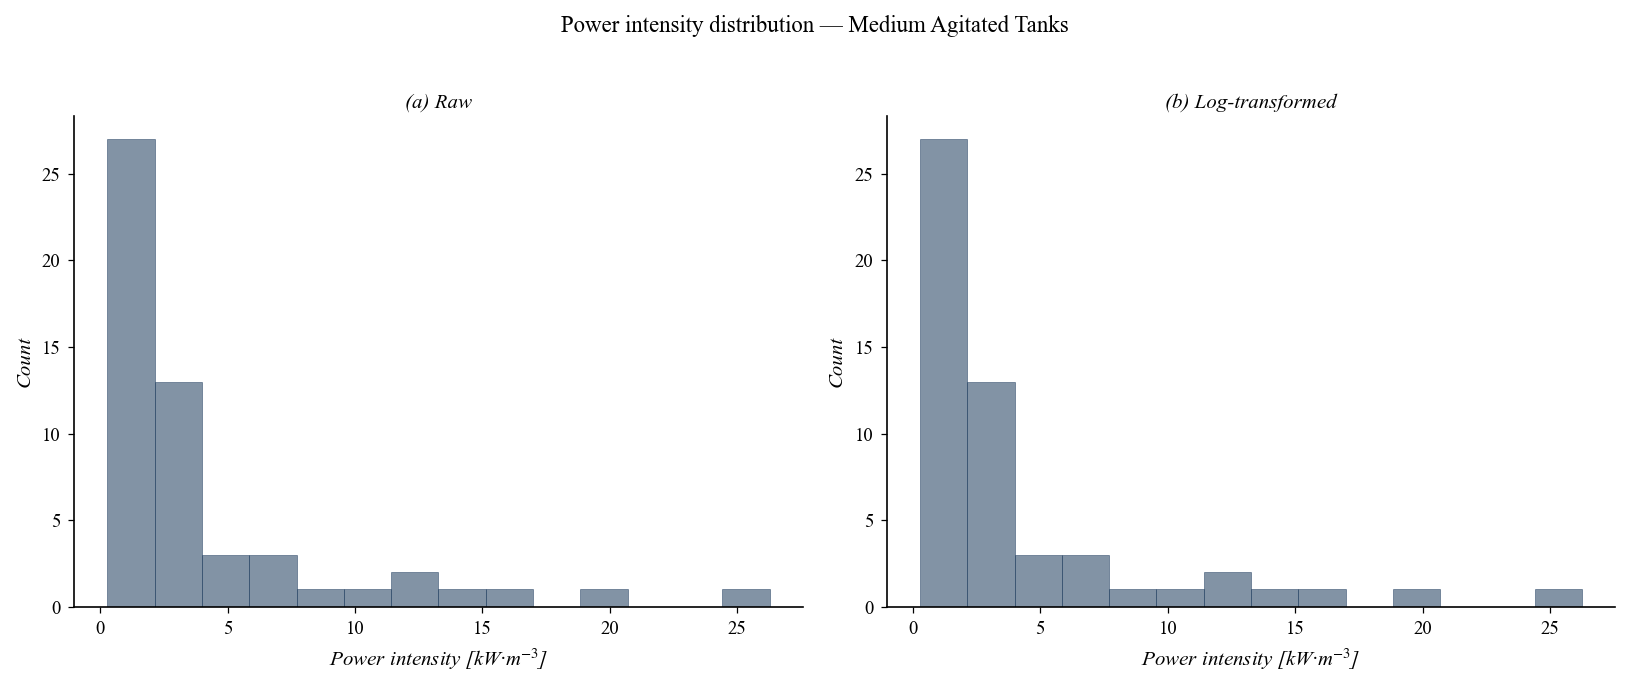

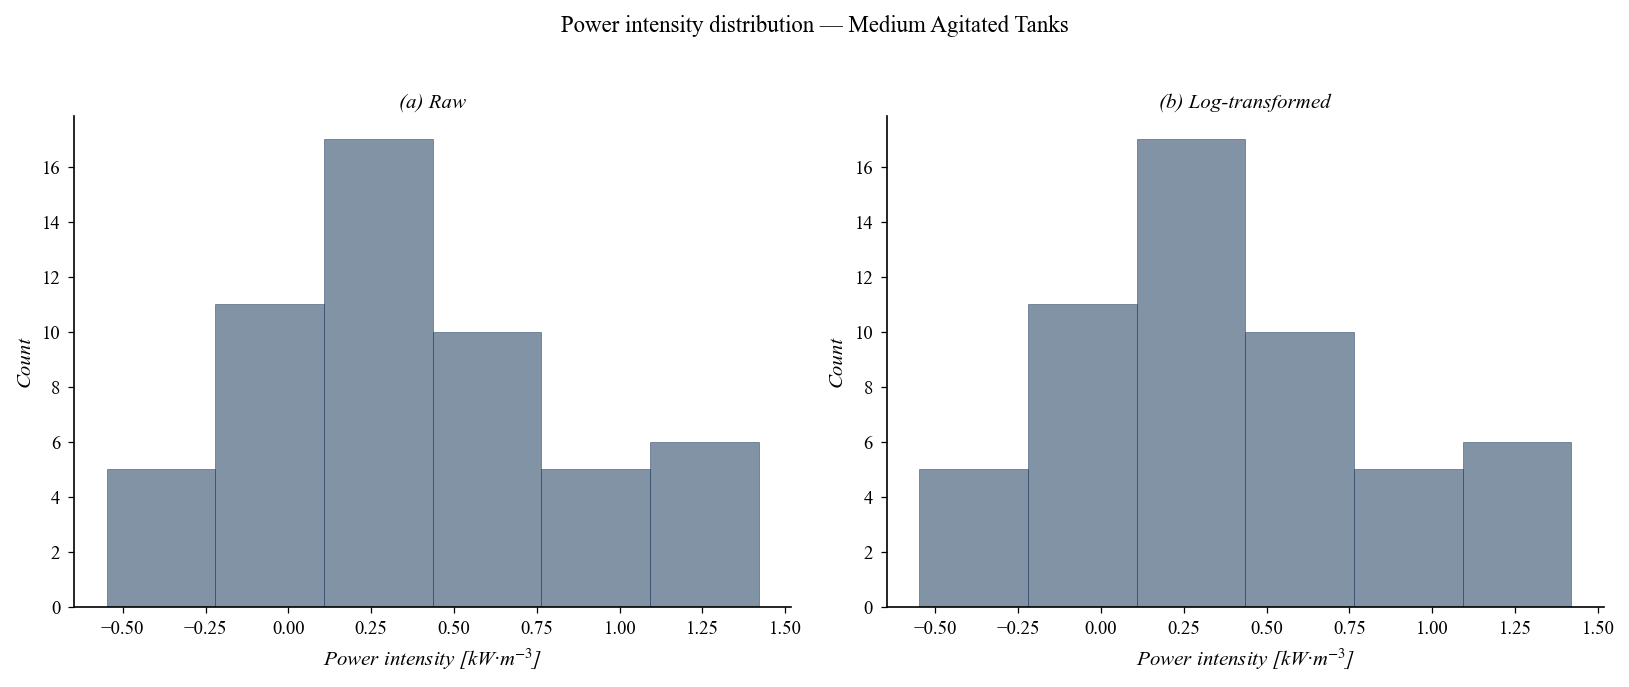


Kolmogorov–Smirnov Test Results for Group 2:
  Distribution  KS Statistic       p-value
0   Log-normal        0.0692  9.421644e-01
1       Normal        0.2734  4.667872e-04
2   Triangular        0.4909  1.590336e-12
3      Uniform        0.6000  4.052659e-19 

Group 3: n=58, bins=7


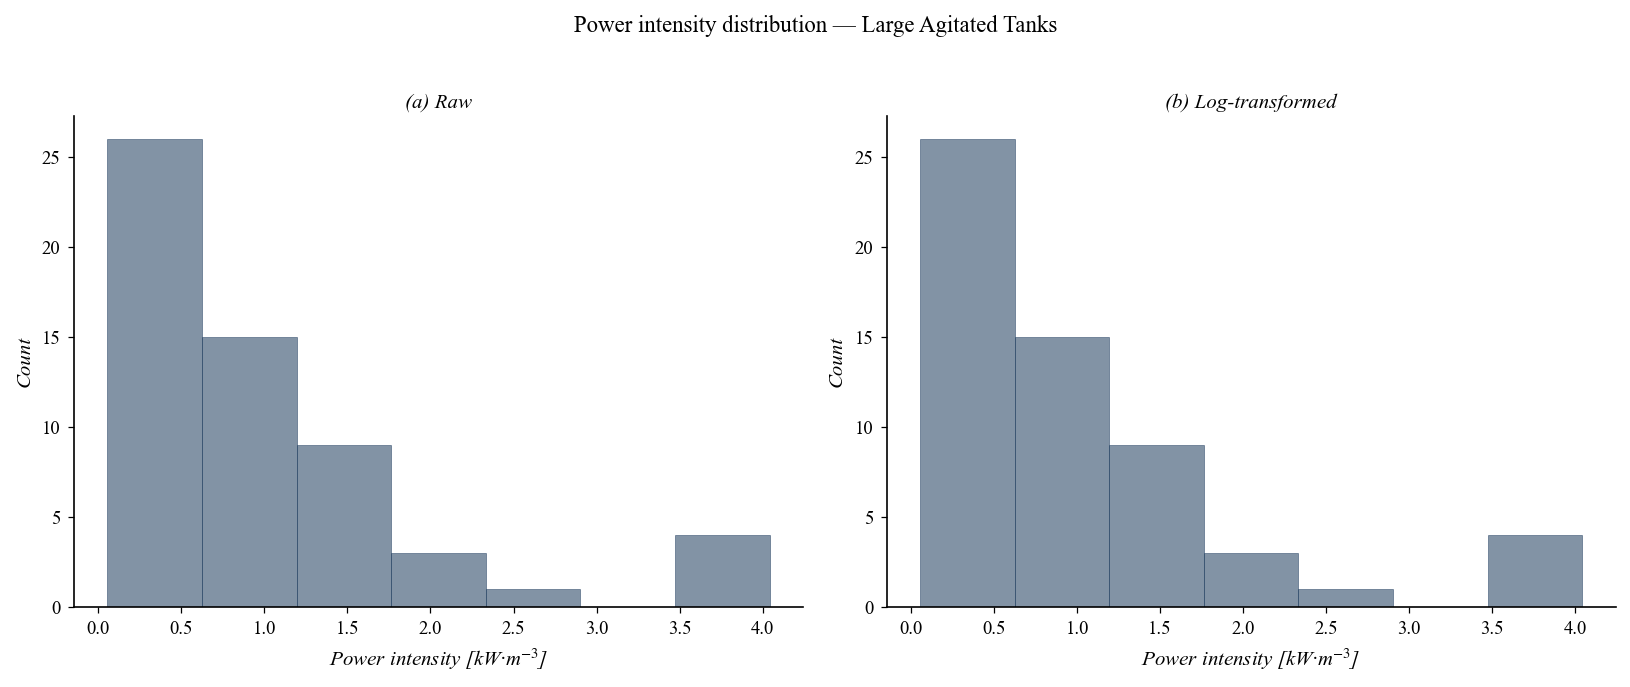

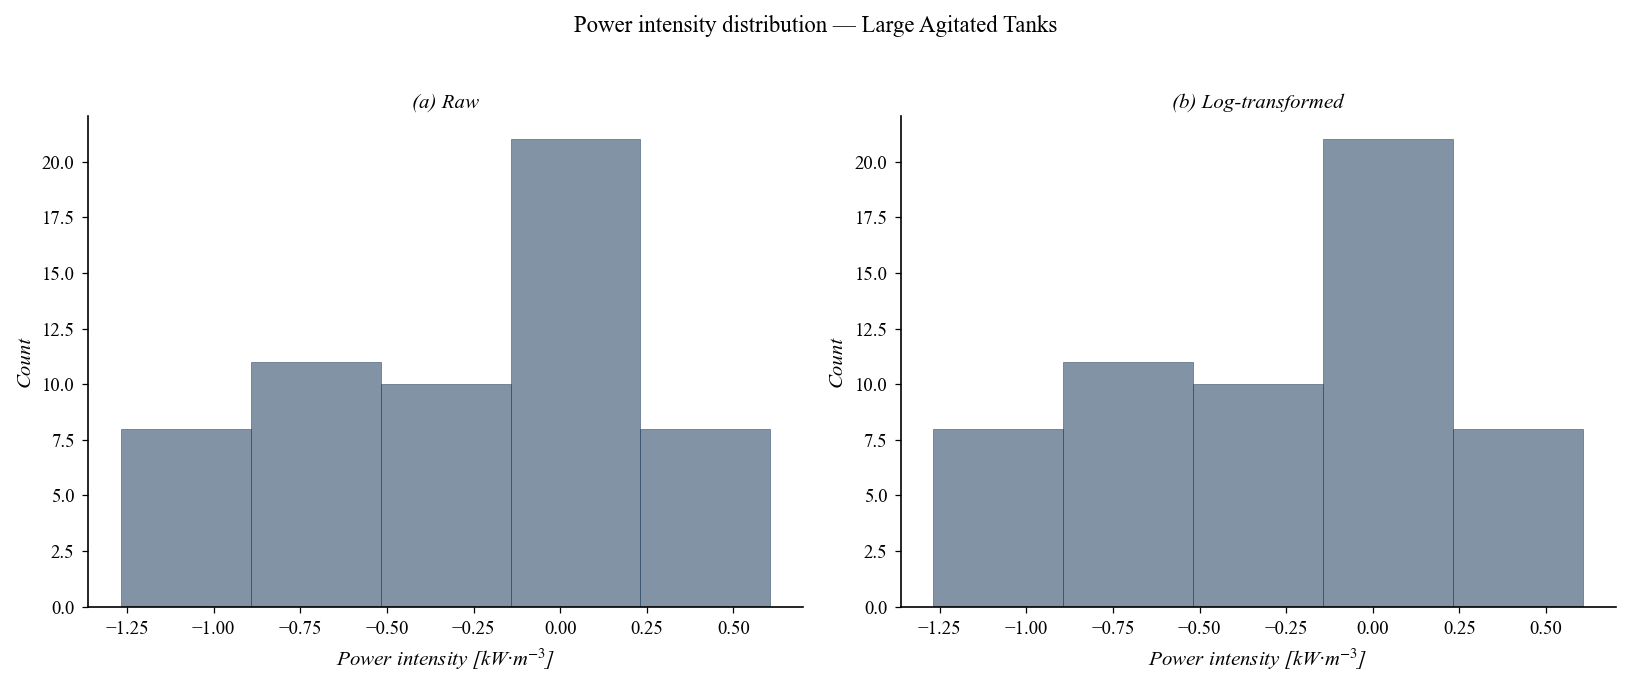


Kolmogorov–Smirnov Test Results for Group 3:
  Distribution  KS Statistic       p-value
0   Log-normal        0.1552  1.095615e-01
1       Normal        0.1721  5.673537e-02
2   Triangular        0.2530  9.257132e-04
3      Uniform        0.4644  5.607744e-12 



In [83]:
indices = np.cumsum([0] + splits_at).tolist()
ks_results_at_groups = {}

for i in range(len(splits_at)):
    start, end = indices[i], indices[i+1]
    subset = agitated_tanks_clean.iloc[start:end]
    # Freedman–Diaconis bins
    bins = freedman_diaconis_bins(subset["PowerToCapacity_kW·m⁻³"])
    print(f"Group {i+1}: n={len(subset)}, bins={bins}")


    # Plot histogram
    group_name = labels.get(f"Group {i+1}", f"Group {i+1}")
    plot_pv_histogram(df = subset, column_name = "PowerToCapacity_kW·m⁻³", equipment=f"{group_name} Agitated Tanks", unit = "(kW·m⁻³)", bins = bins)
    plot_pv_histogram(df = subset, column_name = "log(PowerToCapacity)", equipment=f"{group_name} Agitated Tanks", unit = "" , bins = bins)
    # Call your existing KS test function
    ks_df = distribution_kolmogorov_smirnov_tests(subset["PowerToCapacity_kW·m⁻³"])

    print(f"\nKolmogorov–Smirnov Test Results for Group {i+1}:")
    print(ks_df, '\n')


In [84]:
print("generating Table S15:\n")
grouped_results_at = summarize_geo_stats(df=agitated_tanks_clean.copy(), y_col="PowerToCapacity_kW·m⁻³", splits=splits_at, bin_labels=bin_labels_at, capacity_unit="Volume_m³", equipment_type="Agitated Tanks")

grouped_results_at

generating Table S15:



,Equipment,"Volume bin, m³",GeometricMean,GeometricStd,95% PI,95% CI for GM,Smearing factor
0,Agitated Tanks,"[0.005, 0.20)",6.382,2.913,"[0.752, 54.144]","[4.420, 9.214]",1.7709
1,Agitated Tanks,"[0.20, 2.00)",2.297,2.995,"[0.256, 20.605]","[1.702, 3.098]",1.8253
2,Agitated Tanks,"[2.00, 135.40)",0.555,3.268,"[0.052, 5.926]","[0.406, 0.757]",2.0163


generating Figure S44:



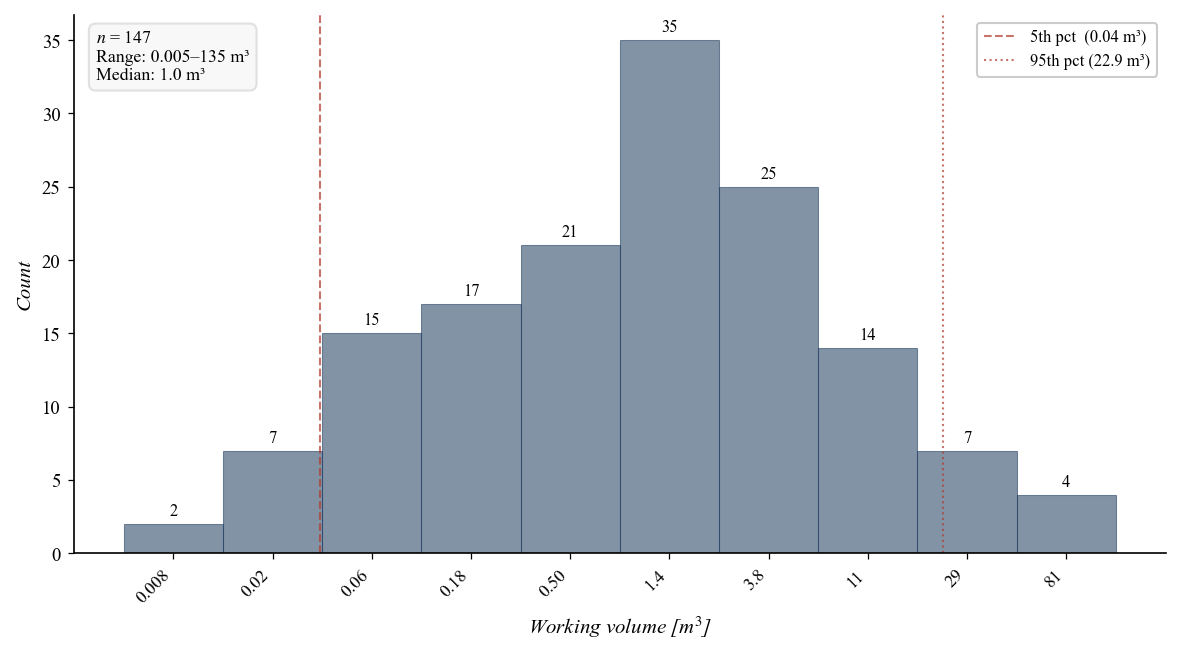

=== Capacity distribution summary — Agitated Tanks (post-outlier removal) ===
  n                : 147
  Min              : 0.0050 m³
  Max              : 135.40 m³
  Median           : 1.003 m³
  5th percentile   : 0.0379 m³
  95th percentile  : 22.89 m³
  Peak bin (mode)  : ~1.4 m³  (n = 35)
  FD bins used     : 10


In [86]:
print("generating Figure S44:\n")
## Capacity Size Distribution — Vendor Dataset Coverage (after outlier removal)
# Shows that vendor listings are concentrated in mid-range commercial sizes,
# with tails (very small and very large equipment) thinly sampled.

# ── 1. Data preparation ──────────────────────────────────────────────────────
volumes = agitated_tanks_clean["Volume_m³"].dropna().values
log_volumes = np.log10(volumes)

# ── 2. Bin width: Freedman–Diaconis on log10(V) ──────────────────────────────
# Applied on log scale to respect lognormal distribution of capacity data.
# Produces bins of equal width in log space → equal width on log x-axis.
n_bins = freedman_diaconis_bins(log_volumes)
bin_edges_log = np.linspace(log_volumes.min(), log_volumes.max(), n_bins + 1)
bin_edges_raw = 10 ** bin_edges_log  # back-transform for x-tick labels

counts, _ = np.histogram(log_volumes, bins=bin_edges_log)

# ── 3. Bin centers and labels ─────────────────────────────────────────────────
bin_centers_log = 0.5 * (bin_edges_log[:-1] + bin_edges_log[1:])
bin_centers_raw = 10 ** bin_centers_log

# Format x-tick labels as rounded raw volumes (m³)
def _fmt_vol(v):
    if v < 0.01:   return f"{v:.3f}"
    elif v < 1:    return f"{v:.2f}"
    elif v < 10:   return f"{v:.1f}"
    else:          return f"{v:.0f}"

tick_labels = [_fmt_vol(v) for v in bin_centers_raw]

# ── 4. Identify peak bin (mode) for annotation ───────────────────────────────
peak_idx   = np.argmax(counts)
peak_count = counts[peak_idx]
peak_vol   = bin_centers_raw[peak_idx]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    bin_centers_log,
    counts,
    width=np.diff(bin_edges_log),
    color=OBS_COLOR,
    alpha=0.55,
    edgecolor=OBS_COLOR,
    linewidth=0.5,
    align="center",
)

# Count labels on top of each bar
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(count),
            ha="center", va="bottom",
            fontsize=8, color="black",
        )

# Vertical dashed lines at dataset tails (5th and 95th percentile of log V)
p5  = np.percentile(log_volumes, 5)
p95 = np.percentile(log_volumes, 95)
ax.axvline(p5,  color="#B03A2E", linewidth=1.0, linestyle="--", alpha=0.7,
           label=f"5th pct  ({10**p5:.2f} m³)")
ax.axvline(p95, color="#B03A2E", linewidth=1.0, linestyle=":",  alpha=0.7,
           label=f"95th pct ({10**p95:.1f} m³)")

# ── 6. Axes formatting ────────────────────────────────────────────────────────
ax.set_xticks(bin_centers_log)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8.5)
ax.set_xlabel("Working volume [m$^3$]", style="italic", fontsize=10)
ax.set_ylabel("Count", style="italic", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=8, frameon=True, facecolor="white",
          edgecolor="#cccccc", loc="upper right")

# Summary stats text box
n_total = len(volumes)
v_min   = volumes.min()
v_max   = volumes.max()
v_med   = np.median(volumes)
ax.text(
    0.02, 0.97,
    f"$n$ = {n_total}\n"
    f"Range: {_fmt_vol(v_min)}–{_fmt_vol(v_max)} m³\n"
    f"Median: {_fmt_vol(v_med)} m³",
    transform=ax.transAxes,
    fontsize=8.5, color="black",
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f8f8f8",
              edgecolor="#dddddd", alpha=0.9),
)

plt.tight_layout()
plt.show()

# ── 7. Numerical summary ──────────────────────────────────────────────────────
print("=== Capacity distribution summary — Agitated Tanks (post-outlier removal) ===")
print(f"  n                : {n_total}")
print(f"  Min              : {v_min:.4f} m³")
print(f"  Max              : {v_max:.2f} m³")
print(f"  Median           : {v_med:.3f} m³")
print(f"  5th percentile   : {10**p5:.4f} m³")
print(f"  95th percentile  : {10**p95:.2f} m³")
print(f"  Peak bin (mode)  : ~{_fmt_vol(peak_vol)} m³  (n = {peak_count})")
print(f"  FD bins used     : {n_bins}")